In [1]:
print(4, 1, 2, sep=',', end='')
print(3, 5, sep='/')

4,1,23/5


# [1교시]

# 1: LLM의 이해와 법률 데이터 분석

- 자연어 처리(NLP)와 LLM의 기본 처리 흐름을 설명할 수 있다.
- 토큰, 임베딩, 문맥, 프롬프트가 분류 결과에 어떤 영향을 주는지 이해한다.
- 법률 조항을 6개 카테고리로 분류할 때 필요한 판정 기준을 적용할 수 있다.
- 간단한 데이터 탐색을 통해 카테고리 분포, 길이, 핵심 표현, 애매한 사례를 확인할 수 있다.
- 규칙 기반 분류의 한계를 확인하고, 이후 LLM 프롬프트 최적화가 왜 필요한지 설명할 수 있다.

---

## 1. 자연어 처리(NLP) 기초

### 1.1 NLP란 무엇인가?

자연어 처리(Natural Language Processing, NLP)는 사람이 쓰는 언어를 컴퓨터가 처리할 수 있도록 표현하고 분석하는 기술입니다. 법률 문서에서는 단어 하나의 차이가 권리, 의무, 절차, 처벌의 의미를 바꿀 수 있기 때문에 일반 문장보다 더 세심한 처리가 필요합니다.

**m6_mermaid_visualization**: 자연어 처리(NLP) 및 LLM 처리 흐름


![alt text](image.png)


### 1.2 토크나이제이션

토크나이제이션은 텍스트를 모델이 처리할 수 있는 작은 단위인 토큰으로 나누는 과정입니다. 토큰은 반드시 사람이 생각하는 단어와 같지는 않습니다. 한국어는 조사, 어미, 복합명사가 많기 때문에 같은 표현도 토크나이저에 따라 다르게 쪼개질 수 있습니다.

예시:

- 문장: `법원은 피고인에게 징역 3년을 선고했다.`
- 사람이 보는 단위: `법원 / 피고인 / 징역 / 선고`
- 단순 공백 기준 토큰: `["법원은", "피고인에게", "징역", "3년을", "선고했다."]`

이 차이는 분류 작업에서 중요합니다. 예를 들어 `징역`, `벌금`, `처한다`는 처벌 조항을 강하게 암시하지만, `절차에 따른다`는 권리 구제 절차일 수도 있고 단순 위임 조항일 수도 있습니다.

### 1.3 임베딩

임베딩은 텍스트를 숫자 벡터로 바꾸어 의미적 유사성을 계산할 수 있게 만드는 표현 방식입니다.

- `법원`, `판사`, `재판`은 비슷한 문맥에서 자주 등장하므로 가까운 표현으로 학습될 가능성이 큽니다.
- `법원`과 `빵`은 문맥이 크게 다르므로 상대적으로 먼 표현이 됩니다.

단, 임베딩은 정답 그 자체가 아닙니다. 법률 문장에서는 `청구할 수 있다`가 권리를 뜻할 수도 있고, 특정 절차의 일부를 뜻할 수도 있습니다. 따라서 분류 기준과 문맥 검토가 함께 필요합니다.

---

## 2. LLM의 작동 원리

### 2.1 LLM이 하는 일

LLM(Large Language Model)은 대규모 텍스트를 학습한 언어 모델입니다. 기본적으로는 앞의 문맥을 보고 다음에 올 가능성이 높은 토큰의 확률분포를 계산합니다.

예시:

```text
입력: 이 법에서 사용하는 용어의
높은 확률 후보: 정의, 뜻, 범위 ...
```

이 과정을 반복하면 문장이 생성됩니다. 분류 작업에서는 이 생성 능력을 이용해 모델에게 `DEF`, `RIGHT`, `PROC` 같은 제한된 라벨 중 하나를 고르게 합니다.

### 2.2 분류에서 LLM을 사용할 때의 핵심

분류는 단순히 문장을 읽고 라벨을 붙이는 작업처럼 보이지만, 실제로는 다음 세 요소가 결과를 크게 좌우합니다.

| 요소 | 의미 | 예시 |
|---|---|---|
| 라벨 정의 | 각 카테고리의 경계 | `권리 및 의무`와 `절차 및 처벌`의 차이 |
| 입력 문맥 | 조항 번호, 장 제목, 앞뒤 문장 | `제1조 목적`, `제2조 정의` |
| 출력 형식 | 모델이 답해야 하는 방식 | `카테고리 코드만 출력` |

이후 차시에서는 이 세 요소를 프롬프트로 제어하면서 성능을 비교합니다.

---

## 3. 법률 조항 6개 카테고리

### 3.1 카테고리 정의

이 과정에서는 법률 조항을 다음 6개 카테고리로 분류합니다.

| 카테고리명 | 코드 | 핵심 판정 기준 | 대표 표현 |
|---|---|---|---|
| 정의 및 범위 | DEF | 법의 목적, 용어 정의, 적용 범위를 설명한다 | `목적으로 한다`, `정의`, `적용한다`, `범위` |
| 권리 및 의무 | RIGHT | 개인, 기관, 사업자 등의 권리·의무·금지·책임을 규정한다 | `권리를 가진다`, `하여야 한다`, `금지한다`, `책임` |
| 절차 및 처벌 | PROC | 신청, 심사, 조사, 소송, 불복, 처벌, 제재 절차를 규정한다 | `신청`, `심사`, `절차`, `징역`, `벌금`, `처한다` |
| 조직 및 기구 | ORG | 위원회, 기관, 법원 등 조직의 설치·구성·권한을 규정한다 | `설치한다`, `구성`, `위원`, `권한`, `관장한다` |
| 기준 및 요건 | CRIT | 자격, 기준, 요건, 기간, 수치 조건을 제시한다 | `이상`, `이하`, `요건`, `기준`, `자격` |
| 기타 조항 | ETC | 부칙, 시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항 | `시행한다`, `대통령령으로 정한다`, `경과조치` |

### 3.2 우선 판정 순서

한 조항에는 여러 신호가 함께 들어갈 수 있습니다. 이때는 다음 순서로 판단하면 일관성을 높일 수 있습니다.

1. 조항의 주된 기능이 무엇인지 본다.
2. 법의 목적·정의·적용 범위이면 `DEF`를 우선 검토한다.
3. 조직의 설치·구성·권한이 중심이면 `ORG`를 선택한다.
4. 명시적인 자격·수치·기준이 중심이면 `CRIT`를 선택한다.
5. 신청·심사·처분·불복·처벌의 흐름이 중심이면 `PROC`를 선택한다.
6. 권리·의무·금지·책임이 중심이면 `RIGHT`를 선택한다.
7. 시행일, 위임, 경과조치처럼 실체적 규율보다 문서 운영에 가까우면 `ETC`를 선택한다.

이 순서는 절대 규칙이 아니라 실습을 위한 기준입니다. 실제 법률 분석에서는 조항 제목, 법 체계, 관련 조문까지 함께 확인해야 합니다.

### 3.3 애매한 사례

| 문장 | 후보 | 검토 포인트 |
|---|---|---|
| `사업자는 안전조치를 갖춘 경우에만 서비스를 제공할 수 있다.` | RIGHT, CRIT | 의무 규정이 핵심이면 RIGHT, 제공 가능 조건이 핵심이면 CRIT |
| `위반 사실이 확인된 경우 장관은 등록을 취소할 수 있다.` | RIGHT, PROC | 행정처분 절차와 제재가 핵심이면 PROC |
| `위원회는 분쟁 조정에 관한 사항을 심의한다.` | ORG, PROC | 위원회 권한 설명이면 ORG, 조정 절차 설명이면 PROC |
| `세부 기준은 대통령령으로 정한다.` | CRIT, ETC | 기준 내용 자체가 없고 위임만 있으면 ETC |

이런 모호성 때문에 단순 키워드 방식은 쉽게 흔들립니다. LLM은 문맥을 더 잘 활용할 수 있지만, 명확한 라벨 정의와 예시가 없으면 역시 일관성이 떨어집니다.

---

실습에서는 다음을 확인합니다.

- 샘플 법률 조항 데이터셋을 만든다.
- 카테고리별 개수, 길이, 핵심 표현을 분석한다.
- 단순 규칙 기반 분류기를 만들어 기준선 성능을 확인한다.
- 애매한 문장을 넣어 규칙 기반 접근의 한계를 확인한다.

좋은 프롬프트를 만들기 전에 **데이터와 라벨 기준을 먼저 이해하는 것**이 핵심입니다.

---

## 5. 법률 데이터 분석 시 주의점

### 5.1 법률 자문이 아니다

이 과정의 분류는 교육용 텍스트 분석 실습입니다. 실제 법적 판단, 소송 전략, 계약 검토, 규제 준수 판단을 대체하지 않습니다.

### 5.2 개인정보와 민감정보

실제 판례, 민원, 계약서, 수사기록 등을 다룰 때는 이름, 주민등록번호, 주소, 사건번호 등 식별 가능 정보를 제거해야 합니다. 외부 API를 사용할 때는 기관의 보안 정책과 데이터 반출 기준도 확인해야 합니다.

### 5.3 정답 라벨의 일관성

모델 성능은 정답 라벨의 품질을 넘기 어렵습니다. 같은 유형의 문장이 어떤 때는 `RIGHT`, 어떤 때는 `PROC`로 라벨링되어 있으면 모델도 안정적으로 학습하거나 예측하기 어렵습니다.

---

## 용어집

| 용어 | 정의 |
|---|---|
| 자연어 처리 | 사람이 쓰는 언어를 컴퓨터가 분석·생성·분류하도록 만드는 기술 |
| 토큰 | 모델이 텍스트를 처리하는 기본 단위 |
| 토크나이제이션 | 텍스트를 토큰으로 나누는 과정 |
| 임베딩 | 텍스트를 의미를 담은 숫자 벡터로 표현하는 방식 |
| 프롬프트 | LLM에 제공하는 지시문, 입력 데이터, 출력 형식의 묶음 |
| 분류 | 입력 텍스트를 미리 정의한 라벨 중 하나로 배정하는 작업 |
| 기준선 | 개선 효과를 비교하기 위해 먼저 만드는 단순한 방법의 성능 |
| 혼동 사례 | 둘 이상의 라벨 후보가 plausible한 애매한 입력 |



# [2교시]

In [1]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 토크나이제이션

legal_sentence = '법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다'
tokens = legal_sentence.split()
reg_tokens = re.findall(r'[가-힣A-Za-z0-9]+', legal_sentence)
print(f'원문 : {legal_sentence}')
print('\n공백기준')
print(tokens)
print(f'개수 : {len(tokens)}')
print('\n정규표현식 토큰')
print(reg_tokens)
print(f'개수 : {len(reg_tokens)}')

legal_keyword = ['법원','피고인','징역','벌금','선고']
keyword_presence = { keyword : keyword in legal_sentence for keyword in legal_keyword}
print('\n법률 핵심어 포함 여부:')
print(keyword_presence)


원문 : 법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다

공백기준
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

정규표현식 토큰
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

법률 핵심어 포함 여부:
{'법원': True, '피고인': True, '징역': True, '벌금': True, '선고': True}


In [3]:
# 간이 임베딩 과 의미유사도 : 임베딩(문자를 숫자로 바꿈) 과정을 확인
# BOW(Bag of Words) 표현으로 실습

embedding_examples = pd.DataFrame([
    {'id': 'S1', 'label': 'PROC', 'text': '위반한 자는 3년 이하의 징역 또는 벌금에 처한다.'},
    {'id': 'S2', 'label': 'PROC', 'text': '거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.'},
    {'id': 'S3', 'label': 'ORG', 'text': '분쟁 조정을 위하여 조정위원회를 설치한다.'},
    {'id': 'S4', 'label': 'ORG', 'text': '위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.'},
    {'id': 'S5', 'label': 'RIGHT', 'text': '근로자는 안전한 환경에서 일할 권리를 가진다.'},
])
# 간이임베딩
vocabulary = ['징역', '벌금', '처한다', '위원회', '설치', '구성', '권리', '근로자', '안전']

for word in vocabulary:
    embedding_examples[word] = embedding_examples['text'].str.contains(word).astype(int)

vector_columns = vocabulary
print('문장별 간이 임베딩 벡터')
print(embedding_examples[['id','label','text'] + vector_columns])

def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a, dtype=float)
    b = np.array(vec_b, dtype=float)
    denomiator = np.linalg.norm(a) * np.linalg.norm(b)
    if denomiator == 0:
        return 0.0
    return float(np.dot(a,b) / denomiator)

similarity_rows = []
for i in range(len(embedding_examples)):
    row_i = embedding_examples.iloc[i]
    for j in range(i+1, len(embedding_examples)):        
        row_j = embedding_examples.iloc[j]
        sim = cosine_similarity(row_i[vector_columns],row_j[vector_columns])
        similarity_rows.append({
            'pair' : f'{row_i["id"]}-{row_j["id"]}',
            'labels' : f'{row_i["label"]}-{row_j["label"]}',
            'simularity' : round(sim,3),
            'text_a': row_i['text'],
            'text_b': row_j['text']
        })

similarity_df = pd.DataFrame(similarity_rows).sort_values('simularity',ascending=False)
similarity_df

문장별 간이 임베딩 벡터
   id  label                                  text  징역  벌금  처한다  위원회  설치  구성  \
0  S1   PROC          위반한 자는 3년 이하의 징역 또는 벌금에 처한다.   1   1    1    0   0   0   
1  S2   PROC         거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.   0   1    1    0   0   0   
2  S3    ORG               분쟁 조정을 위하여 조정위원회를 설치한다.   0   0    0    1   1   0   
3  S4    ORG  위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.   0   0    0    1   0   1   
4  S5  RIGHT             근로자는 안전한 환경에서 일할 권리를 가진다.   0   0    0    0   0   0   

   권리  근로자  안전  
0   0    0   0  
1   0    0   0  
2   0    0   0  
3   0    0   0  
4   1    1   1  


,pair,labels,simularity,text_a,text_b
0,S1-S2,PROC-PROC,0.816,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.
7,S3-S4,ORG-ORG,0.500,분쟁 조정을 위하여 조정위원회를 설치한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
1,S1-S3,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
2,S1-S4,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
3,S1-S5,PROC-RIGHT,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
4,S2-S3,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
5,S2-S4,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
6,S2-S5,PROC-RIGHT,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
8,S3-S5,ORG-RIGHT,0.000,분쟁 조정을 위하여 조정위원회를 설치한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
9,S4-S5,ORG-RIGHT,0.000,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.,근로자는 안전한 환경에서 일할 권리를 가진다.


In [4]:
# LLM 작동 원리 - 자동회귀식 다음 토큰 예측
# 앞의 토큰을 보고 다음 토큰을 예측한다는 규칙모델을 실습
# 실제로 llm 거대한 신경망으로 다음 토큰을 예측 
# 우리는 법률문장 몇개에서 bigram빈도를 세어서 특정토큰뒤에 어떤 토큰이 자주나오는지 확인

autoregressive_corpus = [
    '이 법은 국민의 권리를 보호함을 목적으로 한다',
    '이 법은 개인정보를 안전하게 보호함을 목적으로 한다',
    '위원회는 분쟁 조정을 위하여 설치한다',
    '위원회는 위원장 1명을 포함하여 구성한다',
    '위반한 자는 벌금에 처한다',
    '위반한 자는 징역에 처한다',
]
def tokenize_for_bigram(text):
    return re.findall(f'[가-힣A-Za-z09]+',text)

# 현재 토큰이 주어졌을때 다음 토큰이 무엇인지 빈도수 계산
bigram_counts = {}
for sentence in autoregressive_corpus:
    tokens = ['<START>'] + tokenize_for_bigram(sentence) + ['<END>']
    for current_token, next_token in zip(tokens, tokens[1:]):  # <START>, '이'   '이','법은'
        bigram_counts.setdefault(current_token,Counter())[next_token] += 1
print('특정 토큰 뒤에 올 가능성인 높은 후보')
for token in ['<START>', '이','법은','위원회는','위반한','자는' ]:
    print(f'{token} -> {bigram_counts.get(token,Counter()).most_common()}')

def generate_by_bigram(seed_token, max_steps=8):
    current = seed_token
    generated = [] if seed_token == '<START>' else [seed_token]
    trace = []
    for _ in range(max_steps):
        candidates = bigram_counts.get(current, Counter())
        if not candidates:
            break
        next_token, count = candidates.most_common(1)[0]
        trace.append({'context': ' '.join(generated) if generated else '<START>', 'next_token': next_token, 'count': count})
        if next_token == '<END>':
            break
        generated.append(next_token)
        current = next_token
    return ' '.join(generated), pd.DataFrame(trace)

특정 토큰 뒤에 올 가능성인 높은 후보
<START> -> [('이', 2), ('위원회는', 2), ('위반한', 2)]
이 -> [('법은', 2)]
법은 -> [('국민의', 1), ('개인정보를', 1)]
위원회는 -> [('분쟁', 1), ('위원장', 1)]
위반한 -> [('자는', 2)]
자는 -> [('벌금에', 1), ('징역에', 1)]


In [5]:
generated_text, generated_trace = generate_by_bigram('<START>')
print('\n생성결과')
print(generated_text)
print('\n생성과정')
print(generated_trace)


생성결과
이 법은 국민의 권리를 보호함을 목적으로 한다

생성과정
                     context next_token  count
0                    <START>          이      2
1                          이         법은      2
2                       이 법은        국민의      1
3                   이 법은 국민의        권리를      1
4               이 법은 국민의 권리를       보호함을      1
5          이 법은 국민의 권리를 보호함을       목적으로      2
6     이 법은 국민의 권리를 보호함을 목적으로         한다      2
7  이 법은 국민의 권리를 보호함을 목적으로 한다      <END>      2


In [6]:
# 법률 데이터 특성  - 중첩성, 맥락의존성,도메인특화성
keyword_rules = {
    'DEF': ['목적', '정의', '뜻', '말한다', '적용한다', '범위'],
    'ORG': ['위원회', '기관', '법원', '설치', '구성', '관장', '지휘'],
    'CRIT': ['기준', '요건', '자격', '이상', '이하', '이내', '자본금'],
    'PROC': ['신청', '심사', '조사', '청문', '소송', '절차', '징역', '벌금', '처한다', '취소', '청구'],
    'RIGHT': ['권리', '의무', '하여야 한다', '금지', '책임', '침해', '차별'],
    'ETC': ['시행', '공포', '경과', '부칙', '대통령령으로 정한다'],
}

def matched_categories(text, rules):
    result = {}
    for category, keywords in rules.items():
        hits = [keyword for keyword in keywords if keyword in text]
        if hits:
            result[category] = hits
    return result

legal_difficulty_cases = pd.DataFrame([
    {
        'case': '중첩성',
        'context': '',
        'text': '개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.',
        'point': '권리, 의무, 절차 신호가 한 문장에 함께 등장한다.',
    },
    {
        'case': '맥락 의존성',
        'context': '제2조 정의',
        'text': '공공기관이란 국가기관과 지방자치단체를 말한다.',
        'point': '본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.',
    },
    {
        'case': '맥락 의존성',
        'context': '부칙',
        'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.',
        'point': '본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.',
    },
    {
        'case': '도메인 특화성',
        'context': '',
        'text': '항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.',
        'point': '항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다.',
    },
])

domain_terms = ['개인정보처리자', '정보주체', '청구', '공공기관', '부칙', '개정규정', '항소인', '판결서', '송달', '상고장']

legal_difficulty_cases['matched_categories'] = legal_difficulty_cases['text'].apply(lambda text: matched_categories(text, keyword_rules))
legal_difficulty_cases['matched_category_count'] = legal_difficulty_cases['matched_categories'].apply(len)
legal_difficulty_cases['domain_terms'] = legal_difficulty_cases['text'].apply(lambda text: [term for term in domain_terms if term in text])
legal_difficulty_cases['domain_term_count'] = legal_difficulty_cases['domain_terms'].apply(len)

result_table = legal_difficulty_cases[['case', 'context', 'text', 'matched_categories', 'matched_category_count', 'domain_terms', 'point']]
print('출력 해석:')
print('- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.')
print('- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.')
print('- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.')
print('- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.')
result_table

출력 해석:
- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.
- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.
- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.
- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.


,case,context,text,matched_categories,matched_category_count,domain_terms,point
0,중첩성,,개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.,"{'PROC': ['절차', '청구'], 'RIGHT': ['하여야 한다']}",2,"[개인정보처리자, 정보주체, 청구]","권리, 의무, 절차 신호가 한 문장에 함께 등장한다."
1,맥락 의존성,제2조 정의,공공기관이란 국가기관과 지방자치단체를 말한다.,"{'DEF': ['말한다'], 'ORG': ['기관']}",2,[공공기관],본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.
2,맥락 의존성,부칙,제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.,"{'DEF': ['적용한다'], 'ETC': ['시행']}",2,[개정규정],본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.
3,도메인 특화성,,항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.,{'CRIT': ['이내']},1,"[항소인, 판결서, 송달, 상고장]","항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다."


In [7]:
# 카테고리 정의표
category_info = [
    {
        'code': 'DEF',
        'name': '정의 및 범위',
        'decision_rule': '법의 목적, 용어 정의, 적용 범위를 설명한다.',
        'signals': ['목적', '정의', '뜻한다', '적용', '범위'],
    },
    {
        'code': 'RIGHT',
        'name': '권리 및 의무',
        'decision_rule': '권리, 의무, 금지, 책임을 규정한다.',
        'signals': ['권리', '의무', '하여야 한다', '금지', '책임'],
    },
    {
        'code': 'PROC',
        'name': '절차 및 처벌',
        'decision_rule': '신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.',
        'signals': ['신청', '심사', '절차', '징역', '벌금', '처한다'],
    },
    {
        'code': 'ORG',
        'name': '조직 및 기구',
        'decision_rule': '기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.',
        'signals': ['위원회', '기관', '설치', '구성', '권한'],
    },
    {
        'code': 'CRIT',
        'name': '기준 및 요건',
        'decision_rule': '자격, 기준, 요건, 기간, 수치 조건을 제시한다.',
        'signals': ['기준', '요건', '자격', '이상', '이하'],
    },
    {
        'code': 'ETC',
        'name': '기타 조항',
        'decision_rule': '시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.',
        'signals': ['시행', '부칙', '경과조치', '대통령령', '공포'],
    },
]

category_df = pd.DataFrame(category_info)
category_df

,code,name,decision_rule,signals
0,DEF,정의 및 범위,"법의 목적, 용어 정의, 적용 범위를 설명한다.","[목적, 정의, 뜻한다, 적용, 범위]"
1,RIGHT,권리 및 의무,"권리, 의무, 금지, 책임을 규정한다.","[권리, 의무, 하여야 한다, 금지, 책임]"
2,PROC,절차 및 처벌,"신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.","[신청, 심사, 절차, 징역, 벌금, 처한다]"
3,ORG,조직 및 기구,"기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.","[위원회, 기관, 설치, 구성, 권한]"
4,CRIT,기준 및 요건,"자격, 기준, 요건, 기간, 수치 조건을 제시한다.","[기준, 요건, 자격, 이상, 이하]"
5,ETC,기타 조항,"시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.","[시행, 부칙, 경과조치, 대통령령, 공포]"


# [3교시]

In [8]:
# 실습용 법률 조항 데이터셋 - 실제는 수집 및 기타등등...
sample_data = [
    {'id': 'D01', 'category': 'DEF', 'text': '이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.'},
    {'id': 'D02', 'category': 'DEF', 'text': '이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.'},
    {'id': 'D03', 'category': 'DEF', 'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.'},
    {'id': 'D04', 'category': 'DEF', 'text': '이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.'},
    {'id': 'R01', 'category': 'RIGHT', 'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.'},
    {'id': 'R02', 'category': 'RIGHT', 'text': '사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.'},
    {'id': 'R03', 'category': 'RIGHT', 'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.'},
    {'id': 'R04', 'category': 'RIGHT', 'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.'},
    {'id': 'P01', 'category': 'PROC', 'text': '이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.'},
    {'id': 'P02', 'category': 'PROC', 'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.'},
    {'id': 'P03', 'category': 'PROC', 'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.'},
    {'id': 'P04', 'category': 'PROC', 'text': '불법행위로 인한 손해배상 청구는 민사소송법에서 정한 절차에 따른다.'},
    {'id': 'O01', 'category': 'ORG', 'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.'},
    {'id': 'O02', 'category': 'ORG', 'text': '위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.'},
    {'id': 'O03', 'category': 'ORG', 'text': '법원은 사법권을 행사하며 대법원, 고등법원 및 지방법원으로 구성된다.'},
    {'id': 'O04', 'category': 'ORG', 'text': '중앙행정기관의 장은 소관 사무를 관장하고 소속 공무원을 지휘한다.'},
    {'id': 'C01', 'category': 'CRIT', 'text': '후보자는 선거일 현재 25세 이상인 국민이어야 한다.'},
    {'id': 'C02', 'category': 'CRIT', 'text': '지원 자격은 해당 분야 경력 3년 이상 및 학사 학위 이상으로 한다.'},
    {'id': 'C03', 'category': 'CRIT', 'text': '안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다.'},
    {'id': 'C04', 'category': 'CRIT', 'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.'},
    {'id': 'E01', 'category': 'ETC', 'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.'},
    {'id': 'E02', 'category': 'ETC', 'text': '이 법 시행 당시 종전의 규정에 따라 한 처분은 이 법에 따른 처분으로 본다.'},
    {'id': 'E03', 'category': 'ETC', 'text': '이 법의 시행에 필요한 사항은 대통령령으로 정한다.'},
    {'id': 'E04', 'category': 'ETC', 'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.'},
]

def simple_tokenize(text):
    return re.findall(r'[가-힣A-Za-z0-9]+', text)

df = pd.DataFrame(sample_data)
df['length'] = df['text'].str.len()
df['tokens'] = df['text'].apply(simple_tokenize)
df['token_count'] = df['tokens'].str.len()

print(f'데이터셋 크기: {len(df)}건')
print(f'카테고리 수: {df["category"].nunique()}개')
df.head(8)

데이터셋 크기: 24건
카테고리 수: 6개


,id,category,text,length,tokens,token_count
0,D01,DEF,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.,43,"[이, 법은, 국민의, 기본적, 인권을, 보호하고, 자유와, 평등을, 실현함을, 목...",11
1,D02,DEF,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.,29,"[이, 법에서, 사용하는, 용어의, 뜻은, 다음, 각, 호와, 같다]",9
2,D03,DEF,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.",41,"[공공기관이란, 국가기관, 지방자치단체, 및, 법령에, 따라, 설치된, 기관을, 말한다]",9
3,D04,DEF,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.,38,"[이, 법은, 대한민국, 영역, 안에서, 이루어지는, 정보, 처리, 행위에, 적용한다]",10
4,R01,RIGHT,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ...",51,"[모든, 국민은, 법, 앞에, 평등하며, 성별, 종교, 또는, 사회적, 신분에, 의...",14
5,R02,RIGHT,사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.,30,"[사업자는, 이용자의, 개인정보를, 안전하게, 관리하여야, 한다]",6
6,R03,RIGHT,근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.,33,"[근로자는, 안전하고, 건강한, 근무, 환경에서, 일할, 권리를, 가진다]",8
7,R04,RIGHT,누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.,38,"[누구든지, 정당한, 사유, 없이, 타인의, 통신비밀을, 침해하여서는, 아니, 된다]",9


In [9]:
# 데이터가 특정 카테고리에 치우쳐있는지 길이차이가 큰지 확인
# 분류데이터의 불균형(자주등장하는 라벨을 선호), 길이가 특정 라벨과 강하게 연결되면 모델이
# 의미보다 길이에 의존
category_counts = df['category'].value_counts().sort_index()
length_stats = df.groupby('category')[['length','token_count']].agg(['count','mean','min','max','std']).round(2)
print('카테고리별 샘플개수')
print(category_counts)
print('\n카테고리별 길이/토큰수 통계')
print(length_stats)

카테고리별 샘플개수
category
CRIT     4
DEF      4
ETC      4
ORG      4
PROC     4
RIGHT    4
Name: count, dtype: int64

카테고리별 길이/토큰수 통계
         length                      token_count                     
          count   mean min max   std       count   mean min max   std
category                                                             
CRIT          4  38.75  29  45  7.14           4  10.50   7  12  2.38
DEF           4  37.75  29  43  6.18           4   9.75   9  11  0.96
ETC           4  34.25  28  43  7.50           4   9.75   7  14  3.10
ORG           4  35.00  31  38  2.94           4   7.75   7   8  0.50
PROC          4  39.75  37  42  2.06           4  10.75   8  12  1.89
RIGHT         4  38.00  30  51  9.27           4   9.25   6  14  3.40


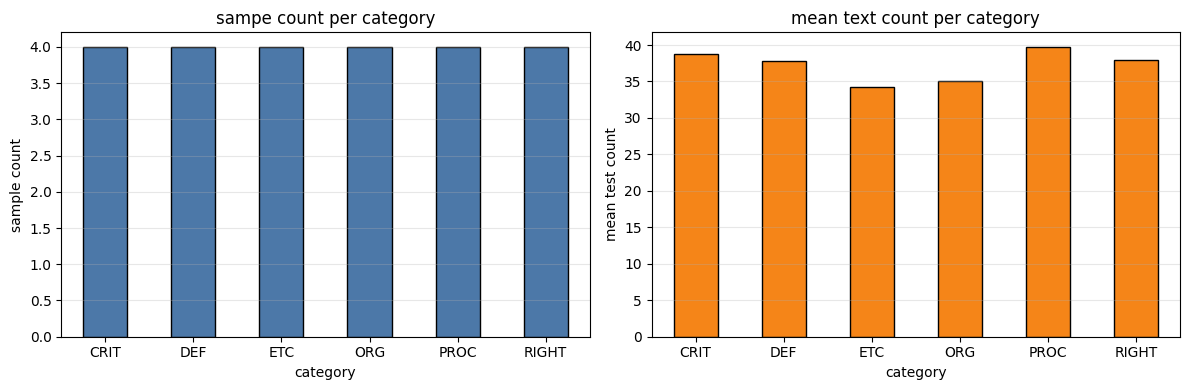

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_counts.plot(kind='bar', ax=axes[0], color='#4C78A8', edgecolor='black')
axes[0].set_title('sampe count per category')
axes[0].set_xlabel('category')
axes[0].set_ylabel('sample count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

mean_length = df.groupby('category')['length'].mean().sort_index()
mean_length.plot(kind='bar', ax=axes[1], color='#F58518', edgecolor='black')
axes[1].set_title('mean text count per category')
axes[1].set_xlabel('category')
axes[1].set_ylabel('mean test count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 카테고리별 대표 문장과 토큰확인
# 법률문장 분류에서는 처한다 위원회  이상 시행한다 같은 표현이 중요한 단서가됨
# 단어하나만으로는 충분하지 않으므로 문장 전체의 기능을 같이 봐야 함

for category in sorted(df['category'].unique()):
    row = df[df['category'] == category].iloc[0]
    name = category_df.set_index('code').loc[category, 'name']
    print(f'[{category}] {name}')
    print(f'문장: {row["text"]}')
    print(f'토큰({row["token_count"]}개): {row["tokens"]}')
    print('-' * 80)

[CRIT] 기준 및 요건
문장: 후보자는 선거일 현재 25세 이상인 국민이어야 한다.
토큰(7개): ['후보자는', '선거일', '현재', '25세', '이상인', '국민이어야', '한다']
--------------------------------------------------------------------------------
[DEF] 정의 및 범위
문장: 이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
토큰(11개): ['이', '법은', '국민의', '기본적', '인권을', '보호하고', '자유와', '평등을', '실현함을', '목적으로', '한다']
--------------------------------------------------------------------------------
[ETC] 기타 조항
문장: 이 법은 공포 후 6개월이 경과한 날부터 시행한다.
토큰(8개): ['이', '법은', '공포', '후', '6개월이', '경과한', '날부터', '시행한다']
--------------------------------------------------------------------------------
[ORG] 조직 및 기구
문장: 분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.
토큰(7개): ['분쟁', '조정을', '위하여', '국무총리', '소속으로', '조정위원회를', '둔다']
--------------------------------------------------------------------------------
[PROC] 절차 및 처벌
문장: 이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
토큰(12개): ['이', '법을', '위반한', '자는', '3년', '이하의', '징역', '또는', '3천만원', '이하의', '벌금에', '처한다']
-----------------------------------------------------

**목적**: 카테고리 정의표의 대표 표현이 실제 샘플에 얼마나 등장하는지 확인합니다.

**Why?** 프롬프트에 카테고리 정의를 넣을 때는 추상적인 설명만 쓰는 것보다 대표 표현을 함께 제시하는 편이 안정적입니다. 단, 대표 표현은 힌트일 뿐 정답 규칙이 아닙니다.

**반환값 설명**:
- `signal_hits`: 각 카테고리의 대표 표현이 전체 데이터에서 발견된 횟수입니다.
- 이 값이 0이어도 해당 카테고리가 틀렸다는 뜻은 아닙니다. 표현이 다른 방식으로 쓰였을 수 있습니다.

In [12]:
signal_rows = []
for _, info in category_df.iterrows():
    for signal in info['signals']:
        hit_count = df['text'].str.contains(re.escape(signal), regex=True).sum()
        signal_rows.append({
            'category': info['code'],
            'signal': signal,
            'hit_count': int(hit_count),
        })

signal_df = pd.DataFrame(signal_rows)
signal_df.sort_values(['category', 'hit_count'], ascending=[True, False])


,category,signal,hit_count
24,CRIT,이상,3
21,CRIT,기준,1
23,CRIT,자격,1
25,CRIT,이하,1
22,CRIT,요건,0
3,DEF,적용,2
0,DEF,목적,1
1,DEF,정의,0
2,DEF,뜻한다,0
4,DEF,범위,0


## 카테고리별 구분 단어 분석

**목적**: 단순히 단어를 세는 데서 끝내지 않고, 어떤 표현이 특정 카테고리를 다른 카테고리와 구분하는지 계산합니다.

**Why?** 많이 등장하는 단어가 항상 좋은 분류 단서는 아닙니다. 예를 들어 `이`, `법`, `한다`는 여러 카테고리에 넓게 나타나므로 구분력이 약합니다. 반대로 `징역`, `위원회`, `시행`처럼 특정 카테고리에 치우친 표현은 분류 근거로 더 유용합니다.

**계산 방식**:
- `category_count`: 해당 카테고리에서 그 토큰이 등장한 문장 수입니다.
- `other_count`: 다른 카테고리에서 그 토큰이 등장한 문장 수입니다.
- `lift`: 특정 카테고리에서 상대적으로 얼마나 더 자주 등장하는지 나타내는 값입니다.
- `lift`가 높을수록 그 카테고리를 구분하는 단서로 볼 수 있습니다.

In [13]:
# 너무 일반적인 법률/문장 표현은 구분 단어 분석에서 제외합니다.
stopwords = {
    '이', '그', '및', '또는', '한다', '있다', '없는', '있는', '따른', '따라', '위하여',
    '법', '법은', '법을', '자는', '날부터', '경우', '각', '호와', '같다'
}

# 같은 문장 안에서 반복된 토큰은 1번만 센다. 문장 수 기준으로 보기 위해서입니다.
doc_token_rows = []
for _, row in df.iterrows():
    unique_tokens = sorted(set(row['tokens']) - stopwords)
    for token in unique_tokens:
        if len(token) < 2:
            continue
        doc_token_rows.append({'id': row['id'], 'category': row['category'], 'token': token})

doc_token_df = pd.DataFrame(doc_token_rows)

discriminative_rows = []
for category in sorted(df['category'].unique()):
    category_doc_count = (df['category'] == category).sum()
    other_doc_count = (df['category'] != category).sum()
    for token in sorted(doc_token_df['token'].unique()):
        category_count = doc_token_df[(doc_token_df['category'] == category) & (doc_token_df['token'] == token)]['id'].nunique()
        other_count = doc_token_df[(doc_token_df['category'] != category) & (doc_token_df['token'] == token)]['id'].nunique()
        if category_count == 0:
            continue
        # 라플라스 보정으로 0 나누기와 과도한 무한대 점수를 피합니다.
        category_rate = (category_count + 1) / (category_doc_count + 2)
        other_rate = (other_count + 1) / (other_doc_count + 2)
        lift = category_rate / other_rate
        discriminative_rows.append({
            'category': category,
            'token': token,
            'category_count': int(category_count),
            'other_count': int(other_count),
            'lift': round(lift, 2),
        })

discriminative_df = pd.DataFrame(discriminative_rows)

top_terms = (
    discriminative_df
    .sort_values(['category', 'lift', 'category_count'], ascending=[True, False, False])
    .groupby('category')
    .head(6)
    .reset_index(drop=True)
)

top_terms

,category,token,category_count,other_count,lift
0,CRIT,1억원,1,0,7.33
1,CRIT,25세,1,0,7.33
2,CRIT,2명,1,0,7.33
3,CRIT,갖추어야,1,0,7.33
4,CRIT,경력,1,0,7.33
5,CRIT,국민이어야,1,0,7.33
6,DEF,공공기관이란,1,0,7.33
7,DEF,국가기관,1,0,7.33
8,DEF,국민의,1,0,7.33
9,DEF,기관을,1,0,7.33


## : 문장별 라벨 점수표 만들기

**목적**: 규칙 기반 분류기가 왜 특정 라벨을 골랐는지 점수표로 확인합니다.

**Why?** `예측=PROC` 같은 결과만 보면 분석이 아니라 출력 확인에 가깝습니다. 라벨별 점수를 같이 보면 어떤 키워드가 어느 라벨을 끌어올렸고, 1등과 2등의 차이가 얼마나 작은지 확인할 수 있습니다.

**출력 해석**:
- `score_*`: 각 카테고리 키워드가 문장에 몇 개 맞았는지 나타냅니다.
- `top_category`: 가장 높은 점수를 받은 라벨입니다.
- `runner_up`: 두 번째 후보 라벨입니다.
- `margin`: 1등 점수와 2등 점수의 차이입니다. 작을수록 애매한 문장입니다.
- `matched_keywords`: 실제로 매칭된 키워드입니다.

In [14]:
def score_by_category(text, rules):
    score = {}
    matched = {}
    for category, keywords in rules.items():
        hits = [keyword for keyword in keywords if keyword in text]
        score[category] = len(hits)
        matched[category] = hits
    return score, matched

def analyze_rule_scores(text):
    score, matched = score_by_category(text, keyword_rules)
    ranked = sorted(score.items(), key=lambda item: (-item[1], item[0]))
    top_category, top_score = ranked[0]
    runner_up, runner_score = ranked[1]
    return {
        'top_category': top_category if top_score > 0 else 'ETC',
        'top_score': top_score,
        'runner_up': runner_up,
        'runner_up_score': runner_score,
        'margin': top_score - runner_score,
        'matched_keywords': {cat: words for cat, words in matched.items() if words},
        **{f'score_{cat}': score[cat] for cat in sorted(keyword_rules)},
    }

score_df = pd.DataFrame([analyze_rule_scores(text) for text in df['text']])
scored_df = pd.concat([df[['id', 'category', 'text']], score_df], axis=1)

scored_df[['id', 'category', 'top_category', 'runner_up', 'margin', 'matched_keywords', 'text']]

,id,category,top_category,runner_up,margin,matched_keywords,text
0,D01,DEF,DEF,CRIT,1,{'DEF': ['목적']},이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
1,D02,DEF,DEF,CRIT,1,{'DEF': ['뜻']},이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.
2,D03,DEF,ORG,DEF,1,"{'DEF': ['말한다'], 'ORG': ['기관', '설치']}","공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
3,D04,DEF,DEF,CRIT,1,{'DEF': ['적용한다']},이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.
4,R01,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['차별']},"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ..."
5,R02,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['하여야 한다']},사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.
6,R03,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['권리']},근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.
7,R04,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['침해']},누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.
8,P01,PROC,PROC,CRIT,2,"{'CRIT': ['이하'], 'PROC': ['징역', '벌금', '처한다']}",이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
9,P02,PROC,CRIT,PROC,0,"{'CRIT': ['이내'], 'PROC': ['신청']}",신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.


##  모호도 분석

**목적**: 어떤 문장이 분류하기 쉬운지, 어떤 문장이 검토가 필요한지 자동으로 표시합니다.

**Why?** 실무에서는 모든 예측을 같은 신뢰도로 다루면 안 됩니다. 1등과 2등 라벨 점수가 비슷한 문장은 사람이 재검토하거나 LLM에게 근거를 요청해야 합니다.

**판정 기준**:
- `no_signal`: 어떤 규칙에도 걸리지 않은 문장입니다.
- `ambiguous`: 1등과 2등 점수 차이가 1 이하인 문장입니다.
- `confident_rule`: 규칙상 비교적 뚜렷한 문장입니다.

In [15]:
def ambiguity_label(row):
    if row['top_score'] == 0:
        return 'no_signal'
    if row['margin'] <= 1 and row['runner_up_score'] > 0:
        return 'ambiguous'
    return 'confident_rule'

scored_df['ambiguity'] = scored_df.apply(ambiguity_label, axis=1)

ambiguity_summary = scored_df.groupby(['category', 'ambiguity']).size().unstack(fill_value=0)
print('카테고리별 모호도 요약')
print(ambiguity_summary)

print('\n검토 우선순위가 높은 문장')
review_targets = scored_df[scored_df['ambiguity'] != 'confident_rule'][
    ['id', 'category', 'top_category', 'runner_up', 'margin', 'ambiguity', 'matched_keywords', 'text']
]
review_targets

카테고리별 모호도 요약
ambiguity  ambiguous  confident_rule
category                            
CRIT               1               3
DEF                1               3
ETC                1               3
ORG                1               3
PROC               1               3
RIGHT              0               4

검토 우선순위가 높은 문장


,id,category,top_category,runner_up,margin,ambiguity,matched_keywords,text
2,D03,DEF,ORG,DEF,1,ambiguous,"{'DEF': ['말한다'], 'ORG': ['기관', '설치']}","공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
9,P02,PROC,CRIT,PROC,0,ambiguous,"{'CRIT': ['이내'], 'PROC': ['신청']}",신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.
13,O02,ORG,ORG,CRIT,1,ambiguous,"{'ORG': ['위원회', '구성'], 'CRIT': ['이내']}",위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.
18,C03,CRIT,CRIT,ETC,0,ambiguous,"{'CRIT': ['기준'], 'ETC': ['대통령령으로 정한다']}","안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다."
23,E04,ETC,DEF,ETC,0,ambiguous,"{'DEF': ['적용한다'], 'ETC': ['시행']}",제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.


##  규칙 기반 기준선 분류기 만들기

**목적**: 대표 표현이 포함되어 있으면 해당 카테고리로 예측하는 단순 분류기를 만듭니다.

**Why?** 기준선은 나중에 LLM 프롬프트 결과와 비교할 최소 성능입니다. 단순 규칙도 일부 문장은 맞히지만, 문맥과 우선순위가 필요한 문장에서는 쉽게 실패합니다.

**주요 파라미터**:
- `keyword_rules`: 카테고리별 탐지 키워드 목록입니다.
- `text`: 분류할 한 문장입니다.

**반환값**:
- 예측 카테고리 코드 1개입니다.
- 어떤 규칙도 맞지 않으면 `ETC`를 반환합니다.

In [16]:
# 우선순위가 있는 규칙 기반 분류기입니다.
# CRIT의 '이하', '이내' 같은 수치 표현이 처벌 조항에도 등장하므로,
# 실제 운영에서는 우선순위 설계가 성능에 큰 영향을 줍니다.
def rule_based_classify(text, priority=None):
    priority = priority or ['DEF', 'ORG', 'CRIT', 'PROC', 'RIGHT', 'ETC']
    score, _ = score_by_category(text, keyword_rules)
    for category in priority:
        if score[category] > 0:
            return category
    return 'ETC'

def evaluate_predictions(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    rows = []
    for label in labels:
        tp = sum((yt == label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fp = sum((yt != label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fn = sum((yt == label) and (yp != label) for yt, yp in zip(y_true, y_pred))
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        rows.append({
            'category': label,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': round(precision, 2),
            'recall': round(recall, 2),
            'f1': round(f1, 2),
        })
    return pd.DataFrame(rows)

df['rule_pred'] = df['text'].apply(rule_based_classify)
df['rule_correct'] = df['category'] == df['rule_pred']

accuracy = df['rule_correct'].mean()
print(f'규칙 기반 기준선 정확도: {accuracy:.1%}')

metrics_df = evaluate_predictions(df['category'], df['rule_pred'])
print('\n카테고리별 성능 지표')
print(metrics_df)

df[['id', 'category', 'rule_pred', 'rule_correct', 'text']]

규칙 기반 기준선 정확도: 87.5%

카테고리별 성능 지표
  category  tp  fp  fn  precision  recall    f1
0     CRIT   4   2   0       0.67    1.00  0.80
1      DEF   4   1   0       0.80    1.00  0.89
2      ETC   3   0   1       1.00    0.75  0.86
3      ORG   4   0   0       1.00    1.00  1.00
4     PROC   2   0   2       1.00    0.50  0.67
5    RIGHT   4   0   0       1.00    1.00  1.00


,id,category,rule_pred,rule_correct,text
0,D01,DEF,DEF,True,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
1,D02,DEF,DEF,True,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.
2,D03,DEF,DEF,True,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
3,D04,DEF,DEF,True,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.
4,R01,RIGHT,RIGHT,True,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ..."
5,R02,RIGHT,RIGHT,True,사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.
6,R03,RIGHT,RIGHT,True,근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.
7,R04,RIGHT,RIGHT,True,누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.
8,P01,PROC,CRIT,False,이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
9,P02,PROC,CRIT,False,신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.


##  오류 사례와 성능 지표 분석

**목적**: 규칙 기반 분류기가 틀린 문장을 직접 확인합니다.

**Why?** 오류 분석은 모델 개선의 출발점입니다. 어떤 문장이 왜 틀렸는지 알아야 다음 차시에서 프롬프트 정의, 예시, 출력 형식을 개선할 수 있습니다.

**출력 해석**:
- `정답`: 사람이 붙인 기준 라벨입니다.
- `예측`: 단순 규칙이 고른 라벨입니다.
- 정답과 예측이 다르면 카테고리 경계 또는 키워드 우선순위를 다시 봐야 합니다.

In [17]:
errors = df[df['rule_correct'] == False].copy()

if errors.empty:
    print('현재 샘플에서는 규칙 기반 분류기가 모두 맞혔습니다. 하지만 새 문장에서는 실패할 수 있습니다.')
else:
    error_details = []
    for _, row in errors.iterrows():
        score, matched = score_by_category(row['text'], keyword_rules)
        error_details.append({
            'id': row['id'],
            'true': row['category'],
            'pred': row['rule_pred'],
            'true_score': score[row['category']],
            'pred_score': score[row['rule_pred']],
            'matched_keywords': {cat: words for cat, words in matched.items() if words},
            'text': row['text'],
        })
    error_df = pd.DataFrame(error_details)
    print(f'오류 {len(error_df)}건')
    print(error_df[['id', 'true', 'pred', 'true_score', 'pred_score', 'matched_keywords', 'text']])

confusion = pd.crosstab(df['category'], df['rule_pred'], rownames=['정답'], colnames=['예측'], dropna=False)
print('\n혼동 행렬')
print(confusion)
confusion

오류 3건
    id  true  pred  true_score  pred_score  \
0  P01  PROC  CRIT           3           1   
1  P02  PROC  CRIT           1           1   
2  E04   ETC   DEF           1           1   

                                matched_keywords  \
0  {'CRIT': ['이하'], 'PROC': ['징역', '벌금', '처한다']}   
1               {'CRIT': ['이내'], 'PROC': ['신청']}   
2               {'DEF': ['적용한다'], 'ETC': ['시행']}   

                                         text  
0  이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.  
1    신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.  
2      제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.  

혼동 행렬
예측     CRIT  DEF  ETC  ORG  PROC  RIGHT
정답                                     
CRIT      4    0    0    0     0      0
DEF       0    4    0    0     0      0
ETC       0    1    3    0     0      0
ORG       0    0    0    4     0      0
PROC      2    0    0    0     2      0
RIGHT     0    0    0    0     0      4


예측,CRIT,DEF,ETC,ORG,PROC,RIGHT
정답,,,,,,
CRIT,4,0,0,0,0,0
DEF,0,4,0,0,0,0
ETC,0,1,3,0,0,0
ORG,0,0,0,4,0,0
PROC,2,0,0,0,2,0
RIGHT,0,0,0,0,0,4


##  규칙 우선순위 실험

**목적**: 같은 키워드 규칙이라도 우선순위를 바꾸면 성능이 어떻게 달라지는지 실험합니다.

**Why?** `이하`, `이내`는 기준·요건(`CRIT`)의 단서이지만, 처벌 조항(`PROC`)에도 자주 등장합니다. 이처럼 법률 텍스트에서는 키워드가 겹치기 때문에 단순 규칙보다 라벨 판정 순서와 문맥 해석이 중요합니다.

**분석 포인트**:
- 가장 좋은 우선순위와 가장 나쁜 우선순위의 정확도를 비교합니다.
- 성능 차이가 크다면, 키워드 방식이 불안정하다는 뜻입니다.

In [18]:
import itertools

labels_without_etc = ['DEF', 'RIGHT', 'PROC', 'ORG', 'CRIT']
priority_results = []

for priority_prefix in itertools.permutations(labels_without_etc):
    priority = list(priority_prefix) + ['ETC']
    preds = [rule_based_classify(text, priority=priority) for text in df['text']]
    acc = np.mean([yt == yp for yt, yp in zip(df['category'], preds)])
    priority_results.append({
        'priority': ' > '.join(priority),
        'accuracy': round(float(acc), 3),
    })

priority_df = pd.DataFrame(priority_results).sort_values('accuracy', ascending=False)

print('상위 우선순위 조합')
print(priority_df.head(5))
print('\n하위 우선순위 조합')
print(priority_df.tail(5))

print('\n정확도 분포')
print(priority_df['accuracy'].describe().round(3))

상위 우선순위 조합
                                 priority  accuracy
0   DEF > RIGHT > PROC > ORG > CRIT > ETC     0.958
8   DEF > PROC > ORG > RIGHT > CRIT > ETC     0.958
48  PROC > DEF > RIGHT > ORG > CRIT > ETC     0.958
15  DEF > ORG > PROC > CRIT > RIGHT > ETC     0.958
14  DEF > ORG > PROC > RIGHT > CRIT > ETC     0.958

하위 우선순위 조합
                                  priority  accuracy
47   RIGHT > CRIT > ORG > PROC > DEF > ETC     0.792
107  CRIT > RIGHT > ORG > PROC > DEF > ETC     0.792
106  CRIT > RIGHT > ORG > DEF > PROC > ETC     0.792
105  CRIT > RIGHT > PROC > ORG > DEF > ETC     0.792
119  CRIT > ORG > PROC > RIGHT > DEF > ETC     0.792

정확도 분포
count    120.000
mean       0.875
std        0.054
min        0.792
25%        0.833
50%        0.875
75%        0.917
max        0.958
Name: accuracy, dtype: float64


##  애매한 실제형 문장 검증

**목적**: 학습 데이터보다 더 애매한 문장을 넣고 사람이 직접 판단해 봅니다.

**Why?** 실무 데이터는 교과서처럼 한 라벨 신호만 담고 있지 않습니다. 권리와 요건, 조직과 절차, 기준과 위임이 한 문장에 같이 나타납니다.

**활동 방법**:
1. `expected_options`를 보기 전에 먼저 스스로 라벨을 예측합니다.
2. 규칙 기반 예측과 비교합니다.
3. 어떤 정보가 추가되면 더 확신할 수 있을지 적어 봅니다.

In [19]:
ambiguous_cases = pd.DataFrame([
    {
        'case_id': 'A01',
        'text': '사업자는 안전관리 기준을 충족한 경우에만 서비스를 제공할 수 있다.',
        'expected_options': 'CRIT 또는 RIGHT',
        'note': '조건이 핵심이면 CRIT, 사업자의 의무/가능 행위가 핵심이면 RIGHT',
    },
    {
        'case_id': 'A02',
        'text': '위원회는 신청인의 이의신청을 접수한 날부터 30일 이내에 심의하여야 한다.',
        'expected_options': 'ORG 또는 PROC',
        'note': '위원회 권한 설명이면 ORG, 이의신청 처리 흐름이면 PROC',
    },
    {
        'case_id': 'A03',
        'text': '세부 안전관리 기준은 대통령령으로 정한다.',
        'expected_options': 'CRIT 또는 ETC',
        'note': '기준 내용이 직접 제시되지 않고 위임만 있으면 ETC에 가까움',
    },
    {
        'case_id': 'A04',
        'text': '개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.',
        'expected_options': 'RIGHT 또는 PROC',
        'note': '정보주체 권리 보장이 핵심이면 RIGHT, 청구 절차가 핵심이면 PROC',
    },
])

ambiguous_cases['rule_pred'] = ambiguous_cases['text'].apply(rule_based_classify)
ambiguous_cases

,case_id,text,expected_options,note,rule_pred
0,A01,사업자는 안전관리 기준을 충족한 경우에만 서비스를 제공할 수 있다.,CRIT 또는 RIGHT,"조건이 핵심이면 CRIT, 사업자의 의무/가능 행위가 핵심이면 RIGHT",CRIT
1,A02,위원회는 신청인의 이의신청을 접수한 날부터 30일 이내에 심의하여야 한다.,ORG 또는 PROC,"위원회 권한 설명이면 ORG, 이의신청 처리 흐름이면 PROC",ORG
2,A03,세부 안전관리 기준은 대통령령으로 정한다.,CRIT 또는 ETC,기준 내용이 직접 제시되지 않고 위임만 있으면 ETC에 가까움,CRIT
3,A04,개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.,RIGHT 또는 PROC,"정보주체 권리 보장이 핵심이면 RIGHT, 청구 절차가 핵심이면 PROC",PROC


## NEXT

LLM에게 단순히 “분류해줘”라고 요청하면 라벨 경계를 자기 방식으로 해석할 수 있습니다. 좋은 프롬프트는 데이터 분석에서 발견한 혼동 지점을 명시적으로 줄여 줍니다.

**정리할 항목**:
- 카테고리 정의를 그대로 넣을 것인가, 짧게 요약할 것인가
- 애매한 사례에서 우선순위를 줄 것인가
- 출력은 코드만 받을 것인가, 근거까지 받을 것인가
- 사람이 검토해야 할 낮은 확신 사례를 어떻게 표시할 것인가

In [20]:
import json
import os
import re
import time
import urllib.request
import urllib.error
from collections import Counter

import numpy as np
import pandas as pd
from dotenv import load_dotenv
load_dotenv(override=True)

print('라이브러리 로드 완료')

python-dotenv could not parse statement starting at line 9


라이브러리 로드 완료


In [21]:
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY','').strip()
OPENAI_MODEL = 'gpt-5-nano'
HF_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'

print(OPENAI_API_KEY[:10] + '...'+OPENAI_API_KEY[-10:])

sk-proj-Gb...Vad7SEhRIA


In [22]:
# 평가 데이터

MAX_SAMPLES = 5 

sample_data = [
    {'id': 'D01', 'category': 'DEF', 'text': '이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.'},
    {'id': 'D02', 'category': 'DEF', 'text': '이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.'},
    {'id': 'D03', 'category': 'DEF', 'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.'},
    {'id': 'D04', 'category': 'DEF', 'text': '이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.'},
    {'id': 'R01', 'category': 'RIGHT', 'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.'},
    {'id': 'R02', 'category': 'RIGHT', 'text': '사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.'},
    {'id': 'R03', 'category': 'RIGHT', 'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.'},
    {'id': 'R04', 'category': 'RIGHT', 'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.'},
    {'id': 'P01', 'category': 'PROC', 'text': '이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.'},
    {'id': 'P02', 'category': 'PROC', 'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.'},
    {'id': 'P03', 'category': 'PROC', 'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.'},
    {'id': 'P04', 'category': 'PROC', 'text': '불법행위로 인한 손해배상 청구는 민사소송법에서 정한 절차에 따른다.'},
    {'id': 'O01', 'category': 'ORG', 'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.'},
    {'id': 'O02', 'category': 'ORG', 'text': '위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.'},
    {'id': 'O03', 'category': 'ORG', 'text': '법원은 사법권을 행사하며 대법원, 고등법원 및 지방법원으로 구성된다.'},
    {'id': 'O04', 'category': 'ORG', 'text': '중앙행정기관의 장은 소관 사무를 관장하고 소속 공무원을 지휘한다.'},
    {'id': 'C01', 'category': 'CRIT', 'text': '후보자는 선거일 현재 25세 이상인 국민이어야 한다.'},
    {'id': 'C02', 'category': 'CRIT', 'text': '지원 자격은 해당 분야 경력 3년 이상 및 학사 학위 이상으로 한다.'},
    {'id': 'C03', 'category': 'CRIT', 'text': '안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다.'},
    {'id': 'C04', 'category': 'CRIT', 'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.'},
    {'id': 'E01', 'category': 'ETC', 'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.'},
    {'id': 'E02', 'category': 'ETC', 'text': '이 법 시행 당시 종전의 규정에 따라 한 처분은 이 법에 따른 처분으로 본다.'},
    {'id': 'E03', 'category': 'ETC', 'text': '이 법의 시행에 필요한 사항은 대통령령으로 정한다.'},
    {'id': 'E04', 'category': 'ETC', 'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.'},
]

label_desc = {
    'DEF': '정의/목적/적용범위 조항',
    'RIGHT': '권리/의무/금지/책임 조항',
    'PROC': '신청/심사/조사/불복/처벌 절차 조항',
    'ORG': '기관/위원회/법원 등 조직의 설치/구성/권한 조항',
    'CRIT': '자격/요건/기준/기간/수치 조건 조항',
    'ETC': '시행일/경과조치/위임 등 기타 조항'
}

df_all = pd.DataFrame(sample_data)
df = df_all.head(MAX_SAMPLES).copy()
print(f'평가 데이터: {len(df)}건 / 전체 {len(df_all)}건')
df.head(5)

평가 데이터: 5건 / 전체 24건


,id,category,text
0,D01,DEF,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
1,D02,DEF,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.
2,D03,DEF,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
3,D04,DEF,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.
4,R01,RIGHT,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ..."


In [23]:
# 프롬프트 템플릿 정의(zero shot / one shot)
ALLOWED = list(label_desc.keys())

SYSTEM_PROMPT = (
    '너는 한국 법률 조항 분류기다, 반드시 다음 6개 코드 중 하나만 선택하라' + 
    ', '.join(ALLOWED) + '. '
    '응답은 반드시 JSON 한 줄로만 반환한다. 형식: {"label" : "DEF","reason":"..."}'
)

LABEL_GUIDE = '\n'.join([f'-{k}:{v}'  for k, v in label_desc.items()])

ONE_SHOT_EXAMPLE = {
    'text' : '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다',
    'output' : {'label':'PROC', 'reason' : '이의신청과 처리 절차를 규정한다'}
}

def build_user_prompt(text, mode='zero'):
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
    ]
    if mode == 'one':
        base += [
            '',
            '예시 1개:',
            f'문장: {ONE_SHOT_EXAMPLE["text"]}',
            '정답(JSON): ' + json.dumps(ONE_SHOT_EXAMPLE['output'], ensure_ascii=False)
        ]
    base += ['', f'분류할 문장: {text}', 'JSON으로만 응답하라.']
    return '\n'.join(base)

print(build_user_prompt('위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.', mode='zero')[:300])


다음 법률 문장을 6개 코드 중 하나로 분류하라.
라벨 설명:
-DEF:정의/목적/적용범위 조항
-RIGHT:권리/의무/금지/책임 조항
-PROC:신청/심사/조사/불복/처벌 절차 조항
-ORG:기관/위원회/법원 등 조직의 설치/구성/권한 조항
-CRIT:자격/요건/기준/기간/수치 조건 조항
-ETC:시행일/경과조치/위임 등 기타 조항

분류할 문장: 위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.
JSON으로만 응답하라.


In [24]:
# openai 호출
from openai import OpenAI
client = OpenAI(api_key = OPENAI_API_KEY)

user_content = build_user_prompt('위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.', mode='zero')
messages = [
    {'role':'system','content':SYSTEM_PROMPT},
    {'role':'user','content':user_content}
]

response = client.responses.create(
    model=OPENAI_MODEL,
    input=messages
)

print(response.output_text)

{"label":"ORG","reason":"위원회의 구성(구성원 수 및 배치)을 다루는 조직 관련 조항이므로 ORG에 해당한다."}


In [25]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
# messages = [
#     {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
#     {"role": "user", "content": prompt}
# ]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(response)


c:\miniconda\envs\edu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6880.96it/s]


{"label": "ORG", "reason": "조직의 설치/구성/권한 조항"}


# [5교시]

In [26]:
# 허깅페이스모델로..  few shot을 만들어서 실습

In [27]:
import json
from typing import Dict, List, Tuple

FEW_SHOT_EXAMPLES = [
    {
        'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.',
        'output': {'label': 'PROC', 'reason': '신청/불복 절차를 규정하는 조항'}
    },
    {
        'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.',
        'output': {'label': 'RIGHT', 'reason': '근로자의 권리를 규정하는 조항'}
    },
    {
        'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.',
        'output': {'label': 'ORG', 'reason': '조직의 설치를 규정하는 조항'}
    }
]

In [28]:
def build_hf_prompt(text:str, mode:str='zero', examples:List[Dict]=None) -> str:
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하세요',
        '라벨 설명:',
        LABEL_GUIDE
    ]
    if mode == 'one':
        base += [
            "",
            "[One-Shot 예시 1개]",
            f'문장:{ONE_SHOT_EXAMPLE["text"]}',
            "정답(JSON): " + json.dumps(ONE_SHOT_EXAMPLE['output'], ensure_ascii=False)
        ]
    elif mode =='few' and examples:
        base += ["", f'[Few-Shot 예시 {len(examples)}]개']
        for i , ex in enumerate(examples, 1):
            base += [
                f'예시 {i}',
                f' 문장 : {ex["text"]}',
                f' 정답 :' + json.dumps(ex['output'], ensure_ascii=False)
            ]
    base += [
        "",
        f"분류할 문장: {text}",
        "응답형식 : ",
        '{"label":"DEF|RIGHT|PROC|ORG|CRIT|ETC", "reason":"분류 근거"}'        
    ]
    return "\n".join(base)

# 테스트 데이터: 실제 평가셋의 문장들 (Real Data)
test_sentences = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'description': '자격/요건 규정'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'description': '시행일 규정'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'description': '정의 규정'
    }
]

results = []
print("hugging face 모델 one-shot / few-shot 비교")
print(f'모델 : {model_name}')
print(f'평가문장 : {len(test_sentences)}')
print(f'few-shot 예시 : {len(FEW_SHOT_EXAMPLES)}')

hugging face 모델 one-shot / few-shot 비교
모델 : Qwen/Qwen2.5-0.5B-Instruct
평가문장 : 3
few-shot 예시 : 3


In [29]:
test_sentences[0]

{'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
 'true_label': 'CRIT',
 'description': '자격/요건 규정'}

In [30]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6541.72it/s]


In [31]:
test_sentences[0]

{'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
 'true_label': 'CRIT',
 'description': '자격/요건 규정'}

In [35]:
def generate_hf_model(text, generate_kwargs=None,mode = 'one'):
    prompt = build_hf_prompt(text,mode,examples=FEW_SHOT_EXAMPLES if mode == 'few' else None)
    messages = [
        {"role":"system","content": SYSTEM_PROMPT },
        {"role":"user", "content" : prompt}
    ]
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    if not generate_kwargs :
        generate_kwargs = {
            'max_new_tokens':512,
            'temperature':0.3,
            'top_p':0.9
        }
    generated_ids = model.generate(
        **model_inputs,   
        **generate_kwargs             
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

In [33]:
test_sentences[0]

{'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
 'true_label': 'CRIT',
 'description': '자격/요건 규정'}

# [6교시]

In [ ]:
# 파라메터 튜닝
# temperature, top_p ,max_output_tokens
HF_EXPERIMENTS = [
    {
        'name':'deterministic',
        'do_sample' : False,
        'temperature' : 0.0,
        'top_p' : 1.0,
        'max_new_tokens':120,
        'description' : '가장 안정적인 설정'
    },
    {
        'name':'blanced',
        'do_sample' : True,
        'temperature' : 0.3,
        'top_p' : 0.9,
        'max_new_tokens':120,
        'description' : '균형잡힌 설정'
    },
    {
        'name':'creative',
        'do_sample' : True,
        'temperature' : 0.8,
        'top_p' : 0.95,
        'max_new_tokens':120,
        'description' : '변동성을 일부 허용하는 설정'
    }
]

TUNING_SAMPLES = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 기준이 있는 요건 조항'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일을 정하는 조항'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '개념의 뜻을 정의하는 조항'
    }
]

results = []
for exp in HF_EXPERIMENTS:
    sample = TUNING_SAMPLES[0]
    text = sample['text']
    kwargs = {
        'do_sample':exp['do_sample'],
        'temperature':exp['temperature'],
        'top_p':exp['top_p'],
        'max_new_tokens':exp['max_new_tokens']
    }
    result = generate_hf_model(text,kwargs,mode='few')
    results.append(result)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [38]:
results, TUNING_SAMPLES[0]

(['{"label":"DEF", "reason":"분류 근거"}',
  '{"label":"PROC", "reason":"신청/불복 절차를 규정하는 조항"}',
  '{"label":"DEF", "reason":"정의/목적/적용범위 조항"}'],
 {'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
  'true_label': 'CRIT',
  'note': '수치 기준이 있는 요건 조항'})

### Few Shot 개수를늘려서 성능 비교(개수에 따른 성능비교)

In [39]:
def extract_json_object(text):
    """모델 응답에서 JSON 객체만 안전하게 추출한다."""
    start = text.find('{')
    end = text.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None

FEW_SHOT_VARIANTS = {
    0: [],
    1: [FEW_SHOT_EXAMPLES[0]],
    3: FEW_SHOT_EXAMPLES[:3],
    5: FEW_SHOT_EXAMPLES + [
        {
            'text': '이 법 시행에 필요한 사항은 대통령령으로 정한다.',
            'output': {'label': 'ETC', 'reason': '시행에 필요한 사항을 위임하는 조항'}
        },
        {
            'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.',
            'output': {'label': 'RIGHT', 'reason': '평등권과 차별 금지를 규정하는 조항'}
        }
    ]
}

EVAL_SAMPLES = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 기준이 있는 요건 조항'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일을 정하는 조항'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '개념의 뜻을 정의하는 조항'
    },
    {
        'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.',
        'true_label': 'RIGHT',
        'note': '금지와 보호의무를 함께 가진 조항'
    },
    {
        'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.',
        'true_label': 'PROC',
        'note': '조사와 청문 절차가 포함된 조항'
    }
]


def build_hf_fewshot_prompt(text, examples):
    """예시 목록을 받아 Few-Shot 프롬프트를 만든다.

    반환값:
        str: 예시 개수가 반영된 최종 프롬프트
    """
    return build_hf_prompt(text, mode='few' if examples else 'zero', examples=examples)


def predict_with_hf(text, examples):
    """Hugging Face 모델로 단일 문장을 분류한다.

    반환값:
        dict: label, reason, raw_response를 포함한 결과
    """
    prompt = build_hf_fewshot_prompt(text, examples)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL',
        'reason': parsed.get('reason') if parsed else raw_response[:160]
    }


print('=' * 90)
print('Few-Shot 예시 개수별 성능 비교')
print('=' * 90)
print('고정 조건: 모델, 평가 문장, 출력 형식, generation 설정')
print('변화 조건: 예시 개수(0, 1, 3, 5)')

fewshot_results = []

for example_count, examples in FEW_SHOT_VARIANTS.items():
    print('\n' + '-' * 90)
    print(f'예시 개수: {example_count}개')
    print('-' * 90)
    
    correct_count = 0
    for sample in EVAL_SAMPLES:
        result = predict_with_hf(sample['text'], examples)
        predicted_label = result['label']
        is_correct = predicted_label == sample['true_label']
        correct_count += int(is_correct)
        
        fewshot_results.append({
            'example_count': example_count,
            'text': sample['text'],
            'true_label': sample['true_label'],
            'predicted_label': predicted_label,
            'correct': is_correct,
            'raw_response': result['raw_response']
        })
        
        print(f"문장: {sample['note']}")
        print(f"정답: {sample['true_label']} / 예측: {predicted_label} / 정답 여부: {'O' if is_correct else 'X'}")
        print(f"이유: {result['reason']}")
        print('-' * 40)
    
    accuracy = correct_count / len(EVAL_SAMPLES)
    print(f'예시 {example_count}개 정확도: {accuracy:.2f}')

fewshot_df = pd.DataFrame(fewshot_results)
fewshot_summary = (
    fewshot_df
    .groupby('example_count', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('example_count')
)

print('\n' + '=' * 90)
print('예시 개수별 요약')
print('=' * 90)
fewshot_summary

Few-Shot 예시 개수별 성능 비교
고정 조건: 모델, 평가 문장, 출력 형식, generation 설정
변화 조건: 예시 개수(0, 1, 3, 5)

------------------------------------------------------------------------------------------
예시 개수: 0개
------------------------------------------------------------------------------------------
문장: 수치 기준이 있는 요건 조항
정답: CRIT / 예측: DEF / 정답 여부: X
이유: 분류 근거
----------------------------------------
문장: 시행일을 정하는 조항
정답: ETC / 예측: DEF / 정답 여부: X
이유: 법률 문장의 목적에 따라 분류
----------------------------------------
문장: 개념의 뜻을 정의하는 조항
정답: DEF / 예측: ORG|PROC|DEF / 정답 여부: X
이유: 문장 내용은 공공기관의 정의와 설치를 포함하고 있습니다.
----------------------------------------
문장: 금지와 보호의무를 함께 가진 조항
정답: RIGHT / 예측: Etc|ORG|PROC / 정답 여부: X
이유: 문장 내용은 특정 조직이나 권한에 따라 적용될 수 있습니다.
----------------------------------------
문장: 조사와 청문 절차가 포함된 조항
정답: PROC / 예측: DEF / 정답 여부: X
이유: 문장 내용은 정의/목적/적용범위 조항으로 분류됩니다.
----------------------------------------
예시 0개 정확도: 0.00

------------------------------------------------------------------------------------------
예시

,example_count,accuracy
0,0,0.0
1,1,0.0
2,3,0.0
3,5,0.2


### 성능올리기
- 예시를 더 추가하는 것보다 라벨 경계 규칙을 프롬프트에 명시하면 성능이 어떻게 달라지는지 비교
- 분류문제의 성능향상 샘플수 늘리는것도 중요하지만 기준을 선명하게 만드는 것이 주요
- 오답분석 관점에서 규칙강화의 효과

- 포인트
    - 기본 프롬프트와 규칙강화 프롬프트의 차이?
    - PROC, ETC, RIGHT, CRIT처럼 경계가 애매한 라벨에서 변화?
    - 출력 형식 고정이되면 안정성에 영향?

In [40]:
RULES_FOR_CONFUSION = [
    'DEF는 정의, 목적, 적용범위처럼 개념을 설명하는 문장이다.',
    'RIGHT는 권리, 의무, 금지, 책임처럼 행위의 허용/금지를 다루는 문장이다.',
    'PROC는 신청, 심사, 조사, 불복, 처벌처럼 절차나 처리 흐름을 다루는 문장이다.',
    'ORG는 위원회, 법원, 기관, 조직의 설치, 구성, 권한을 다루는 문장이다.',
    'CRIT는 자격, 요건, 기준, 기간, 수치 조건처럼 충족해야 할 조건을 다루는 문장이다.',
    'ETC는 시행일, 경과조치, 위임, 부칙처럼 나머지 행정적 규정을 다루는 문장이다.',
    'CRIT와 ETC가 헷갈리면, 숫자나 요건이 있더라도 시행일과 경과조치는 ETC로 우선 판단한다.',
    'PROC와 ETC가 헷갈리면, 절차 자체를 직접 설명하면 PROC, 시행 시기나 부칙이면 ETC로 판단한다.'
]

RULE_AWARE_EVAL = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 요건 문장'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일 문장'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '정의 문장'
    },
    {
        'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.',
        'true_label': 'RIGHT',
        'note': '금지 문장'
    },
    {
        'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.',
        'true_label': 'PROC',
        'note': '조사와 청문 절차 문장'
    }
]

def build_rule_aware_prompt(text):
    """혼동 규칙을 추가한 프롬프트를 생성한다.

    반환값:
        str: 라벨 설명 + 혼동 규칙 + 대상 문장을 포함한 최종 프롬프트
    """
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
        '',
        '구분 규칙:',
    ]
    base.extend([f'- {rule}' for rule in RULES_FOR_CONFUSION])
    base.extend([
        '',
        f'분류할 문장: {text}',
        '반드시 다음 JSON 형식으로만 답하라.',
        '{"label": "DEF|RIGHT|PROC|ORG|CRIT|ETC", "reason": "짧은 근거"}'
    ])
    return '\n'.join(base)

def predict_hf_from_prompt(prompt_text):
    """주어진 프롬프트로 Hugging Face 모델을 호출한다.

    반환값:
        dict: label, reason, raw_response를 포함한 결과
    """
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt_text}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL',
        'reason': parsed.get('reason') if parsed else raw_response[:160]
    }

print('=' * 90)
print('HF 성능 향상 전략: 규칙 강화 비교')
print('=' * 90)
print('전략 1: 기본 zero-shot 프롬프트')
print('전략 2: 경계 규칙을 명시한 rule-aware 프롬프트')

strategy_rows = []

for sample in RULE_AWARE_EVAL:
    baseline_prompt = build_hf_prompt(sample['text'], mode='zero')
    baseline_result = predict_hf_from_prompt(baseline_prompt)
    baseline_correct = baseline_result['label'] == sample['true_label']

    rule_prompt = build_rule_aware_prompt(sample['text'])
    rule_result = predict_hf_from_prompt(rule_prompt)
    rule_correct = rule_result['label'] == sample['true_label']

    strategy_rows.append({
        'strategy': 'baseline',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': baseline_result['label'],
        'correct': baseline_correct,
        'reason': baseline_result['reason']
    })
    strategy_rows.append({
        'strategy': 'rule_aware',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': rule_result['label'],
        'correct': rule_correct,
        'reason': rule_result['reason']
    })

    print('\n' + '-' * 90)
    print(f"문장: {sample['note']}")
    print(f"정답 레이블: {sample['true_label']}")
    print(f"baseline -> {baseline_result['label']} / {'O' if baseline_correct else 'X'} / {baseline_result['reason']}")
    print(f"rule-aware -> {rule_result['label']} / {'O' if rule_correct else 'X'} / {rule_result['reason']}")

strategy_df = pd.DataFrame(strategy_rows)
strategy_summary = (
    strategy_df
    .groupby('strategy', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

print('\n' + '=' * 90)
print('전략별 요약')
print('=' * 90)
strategy_summary

HF 성능 향상 전략: 규칙 강화 비교
전략 1: 기본 zero-shot 프롬프트
전략 2: 경계 규칙을 명시한 rule-aware 프롬프트

------------------------------------------------------------------------------------------
문장: 수치 요건 문장
정답 레이블: CRIT
baseline -> DEF / X / 정의/목적/적용범위 조항
rule-aware -> DEF / X / 정의/목적/적용범위

------------------------------------------------------------------------------------------
문장: 시행일 문장
정답 레이블: ETC
baseline -> DEF / X / 분류 이유: 이 문장은 정의 또는 목적에 대한 정보를 제공하고 있습니다.
rule-aware -> DEF / X / 정의

------------------------------------------------------------------------------------------
문장: 정의 문장
정답 레이블: DEF
baseline -> ORG|PROC|DEF / X / 국가기관과 지방자치단체를 포함하는 공공기관의 정의와 관련
rule-aware -> DEF / O / 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다

------------------------------------------------------------------------------------------
문장: 금지 문장
정답 레이블: RIGHT
baseline -> DEF / X / 정의/목적/적용범위 조항
rule-aware -> DEF / X / 정의에 따라, 누구든지 정당한 사유 없이 타인의 통신 비밀을 침해하여도 되지 않습니다.

------------------------------------------------------------------

,strategy,accuracy
1,rule_aware,0.2
0,baseline,0.0


# [7교시]

In [41]:
# 프롬프트를 개선하고 규칙기반 rule base를 추가해도 성능이 미미한이유는
# 모델크기
# 프롬프트 : 현재 설명+규칙+출력형식을 구성하고있음--> 역으로 작용해서 핵심추론이 막힐수도

# 이 후 개선할 사항
# 1.모델크기 증가
# 2.모델이 잘 이해할수 있도록 입력구조를 단순화

In [46]:
# 출력형식을 제한
    # reason을 제거하고 label만 출력
# ========================================
# 출력 형식 단순화: label only 전략 비교
# ========================================
# reason 생성을 제거하고 label 하나만 맞추는지 본다.
# 작은 모델은 이 방식에서 더 안정적으로 동작하는 경우가 많다.

LABEL_ONLY_EVAL = RULE_AWARE_EVAL


def build_label_only_prompt(text):
    """label만 출력하도록 요구하는 프롬프트를 만든다.

    반환값:
        str: label only 출력 규칙이 포함된 최종 프롬프트
    """
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
        '',
        '추가 규칙:',
        'reason은 쓰지 말고 label만 JSON으로 반환하라.',
        '반드시 다음 형식만 출력하라.',
        '{"label": "DEF|RIGHT|PROC|ORG|CRIT|ETC"}',
        '',
        f'분류할 문장: {text}'
    ]
    return '\n'.join(base)


def predict_label_only(text):
    """label only 프롬프트로 Hugging Face 모델을 호출한다.

    반환값:
        dict: label과 raw_response를 포함한 결과
    """
    prompt_text = build_label_only_prompt(text)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt_text}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL'
    }


print('=' * 90)
print('출력 형식 단순화 전략 비교')
print('=' * 90)
print('전략 1: baseline zero-shot (label + reason)')
print('전략 2: label only 출력')

label_only_rows = []

for sample in LABEL_ONLY_EVAL:
    baseline_prompt = build_hf_prompt(sample['text'], mode='zero')
    baseline_result = predict_hf_from_prompt(baseline_prompt)
    baseline_correct = baseline_result['label'] == sample['true_label']

    label_only_result = predict_label_only(sample['text'])
    label_only_correct = label_only_result['label'] == sample['true_label']

    label_only_rows.append({
        'strategy': 'baseline_reason',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': baseline_result['label'],
        'correct': baseline_correct
    })
    label_only_rows.append({
        'strategy': 'label_only',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': label_only_result['label'],
        'correct': label_only_correct
    })

    print('\n' + '-' * 90)
    print(f"문장: {sample['note']}")
    print(f"정답 레이블: {sample['true_label']}")
    print(f"baseline -> {baseline_result['label']} / {'O' if baseline_correct else 'X'}")
    print(f"label_only -> {label_only_result['label']} / {'O' if label_only_correct else 'X'}")

label_only_df = pd.DataFrame(label_only_rows)
label_only_summary = (
    label_only_df
    .groupby('strategy', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

print('\n' + '=' * 90)
print('출력 형식별 요약')
print('=' * 90)
label_only_summary

print('\n실전 해석')
print('- reason을 빼면 생성 부담이 줄어들어 label 정확도가 올라갈 수 있다.')
print('- 작은 HF 모델은 자유 서술보다 단일 라벨 선택에서 더 안정적이다.')
print('- 그래도 label이 틀리면, 그때는 모델 크기나 데이터 질을 점검해야 한다.')

출력 형식 단순화 전략 비교
전략 1: baseline zero-shot (label + reason)
전략 2: label only 출력

------------------------------------------------------------------------------------------
문장: 수치 요건 문장
정답 레이블: CRIT
baseline -> DEF / X
label_only -> DEF / X

------------------------------------------------------------------------------------------
문장: 시행일 문장
정답 레이블: ETC
baseline -> DEF / X
label_only -> DEF / X

------------------------------------------------------------------------------------------
문장: 정의 문장
정답 레이블: DEF
baseline -> ORG|PROC|DEF / X
label_only -> ORG|PROC|ETC / X

------------------------------------------------------------------------------------------
문장: 금지 문장
정답 레이블: RIGHT
baseline -> DEF / X
label_only -> DEF / X

------------------------------------------------------------------------------------------
문장: 조사와 청문 절차 문장
정답 레이블: PROC
baseline -> DEF / X
label_only -> DEF / X

출력 형식별 요약

실전 해석
- reason을 빼면 생성 부담이 줄어들어 label 정확도가 올라갈 수 있다.
- 작은 HF 모델은 자유 서술보다 단일 라벨 선택에서 더 안정적이다.
- 그래도

In [43]:
# reason을 빼면 생성 부담이 줄어들어서 label 정확도가 올라가는 것을 예상
# 모델이 작으면 자유 서술보다는 라벨선택이 더 유리할수
# 최종적으로는 모델크기나 데이터 질을 점검

# [8교시]

## [runpod으로 실습]

In [45]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
# Runpod GPU 실행 전 1회 설치 셀
# 이 셀을 먼저 실행한 뒤, 커널을 재시작하고 아래 셀부터 다시 순서대로 실행한다.
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-U',
    '--extra-index-url', 'https://download.pytorch.org/whl/cu121',
    'torch==2.7.0',
    'torchvision==0.22.0',
    'torchaudio==2.7.0',
    'transformers>=4.53.3',
    'accelerate>=1.13.0',
    'huggingface_hub>=0.33.0',
    'safetensors',
    'sentencepiece',
    'protobuf',
    'bitsandbytes',
    'einops',
    'peft',
])

In [ ]:
import json
import os
import re
import time
import urllib.request
import urllib.error
from collections import Counter

import numpy as np
import pandas as pd

HF_HOME = os.environ.get('HF_HOME', '/workspace/hf-cache')
HF_HUB_CACHE = os.path.join(HF_HOME, 'hub')
HF_TRANSFORMERS_CACHE = os.path.join(HF_HOME, 'transformers')
os.environ['HF_HOME'] = HF_HOME
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_HUB_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_TRANSFORMERS_CACHE
os.environ['HF_HUB_DISABLE_XET'] = '1'
os.makedirs(HF_HUB_CACHE, exist_ok=True)
os.makedirs(HF_TRANSFORMERS_CACHE, exist_ok=True)

from dotenv import load_dotenv
load_dotenv(override=True)

print('라이브러리 로드 완료')

In [ ]:
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY','').strip()
OPENAI_MODEL = 'gpt-5-nano'
HF_MODEL = 'Qwen/Qwen3.6-27B'

print(OPENAI_API_KEY[:10] + '...'+OPENAI_API_KEY[-10:])

In [ ]:
# 평가 데이터

sample_data = [
    {'id': 'D01', 'category': 'DEF', 'text': '이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.'},
    {'id': 'D02', 'category': 'DEF', 'text': '이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.'},
    {'id': 'D03', 'category': 'DEF', 'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.'},
    {'id': 'D04', 'category': 'DEF', 'text': '이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.'},
    {'id': 'R01', 'category': 'RIGHT', 'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.'},
    {'id': 'R02', 'category': 'RIGHT', 'text': '사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.'},
    {'id': 'R03', 'category': 'RIGHT', 'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.'},
    {'id': 'R04', 'category': 'RIGHT', 'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.'},
    {'id': 'P01', 'category': 'PROC', 'text': '이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.'},
    {'id': 'P02', 'category': 'PROC', 'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.'},
    {'id': 'P03', 'category': 'PROC', 'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.'},
    {'id': 'P04', 'category': 'PROC', 'text': '불법행위로 인한 손해배상 청구는 민사소송법에서 정한 절차에 따른다.'},
    {'id': 'O01', 'category': 'ORG', 'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.'},
    {'id': 'O02', 'category': 'ORG', 'text': '위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.'},
    {'id': 'O03', 'category': 'ORG', 'text': '법원은 사법권을 행사하며 대법원, 고등법원 및 지방법원으로 구성된다.'},
    {'id': 'O04', 'category': 'ORG', 'text': '중앙행정기관의 장은 소관 사무를 관장하고 소속 공무원을 지휘한다.'},
    {'id': 'C01', 'category': 'CRIT', 'text': '후보자는 선거일 현재 25세 이상인 국민이어야 한다.'},
    {'id': 'C02', 'category': 'CRIT', 'text': '지원 자격은 해당 분야 경력 3년 이상 및 학사 학위 이상으로 한다.'},
    {'id': 'C03', 'category': 'CRIT', 'text': '안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다.'},
    {'id': 'C04', 'category': 'CRIT', 'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.'},
    {'id': 'E01', 'category': 'ETC', 'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.'},
    {'id': 'E02', 'category': 'ETC', 'text': '이 법 시행 당시 종전의 규정에 따라 한 처분은 이 법에 따른 처분으로 본다.'},
    {'id': 'E03', 'category': 'ETC', 'text': '이 법의 시행에 필요한 사항은 대통령령으로 정한다.'},
    {'id': 'E04', 'category': 'ETC', 'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.'},
]

label_desc = {
    'DEF': '정의/목적/적용범위 조항',
    'RIGHT': '권리/의무/금지/책임 조항',
    'PROC': '신청/심사/조사/불복/처벌 절차 조항',
    'ORG': '기관/위원회/법원 등 조직의 설치/구성/권한 조항',
    'CRIT': '자격/요건/기준/기간/수치 조건 조항',
    'ETC': '시행일/경과조치/위임 등 기타 조항'
}

MAX_SAMPLES = 24

df_all = pd.DataFrame(sample_data)
df = df_all.head(MAX_SAMPLES).copy()
print(f'평가 데이터: {len(df)}건 / 전체 {len(df_all)}건')
df.head(5)

In [ ]:
# 프롬프트 템플릿 정의(zero shot / one shot)
ALLOWED = list(label_desc.keys())

SYSTEM_PROMPT = (
    '너는 한국 법률 조항 분류기다, 반드시 다음 6개 코드 중 하나만 선택하라' + 
    ', '.join(ALLOWED) + '. '
    '응답은 반드시 JSON 한 줄로만 반환한다. 형식: {"label" : "DEF","reason":"..."}'
)

LABEL_GUIDE = '\n'.join([f'-{k}:{v}'  for k, v in label_desc.items()])

ONE_SHOT_EXAMPLE = {
    'text' : '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다',
    'output' : {'label':'PROC', 'reason' : '이의신청과 처리 절차를 규정한다'}
}

def build_user_prompt(text, mode='zero'):
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
    ]
    if mode == 'one':
        base += [
            '',
            '예시 1개:',
            f'문장: {ONE_SHOT_EXAMPLE["text"]}',
            '정답(JSON): ' + json.dumps(ONE_SHOT_EXAMPLE['output'], ensure_ascii=False)
        ]
    base += ['', f'분류할 문장: {text}', 'JSON으로만 응답하라.']
    return '\n'.join(base)

print(build_user_prompt('위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.', mode='zero')[:300])


In [ ]:
# openai 호출
from openai import OpenAI
client = OpenAI(api_key = OPENAI_API_KEY)

user_content = build_user_prompt('위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.', mode='zero')
messages = [
    {'role':'system','content':SYSTEM_PROMPT},
    {'role':'user','content':user_content}
]

response = client.responses.create(
    model=OPENAI_MODEL,
    input=messages
)

print(response.output_text)

In [ ]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = HF_MODEL

if torch.cuda.is_available():
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    print(f'CUDA 사용 가능: {torch.cuda.get_device_name(0)}')
    print(f'로딩 dtype: {dtype}')
else:
    dtype = torch.float32
    print('CUDA를 찾지 못해 CPU로 로딩합니다.')

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype,
    device_map='auto',
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    attn_implementation='eager',
    cache_dir=HF_HOME,
)
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
    cache_dir=HF_HOME,
)

if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token

prompt = "Give me a short introduction to large language model."
# messages = [
#     {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
#     {"role": "user", "content": prompt}
# ]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(response)


In [ ]:
import json
from typing import Dict, List, Tuple

# Few-Shot 예시 데이터: 각 카테고리별 대표 예시 3개
# 과적합 유도를 위해 테스트 문장과 의도적으로 구분되는 패턴 사용
FEW_SHOT_EXAMPLES = [
    {
        'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.',
        'output': {'label': 'PROC', 'reason': '신청/불복 절차를 규정하는 조항'}
    },
    {
        'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.',
        'output': {'label': 'RIGHT', 'reason': '근로자의 권리를 규정하는 조항'}
    },
    {
        'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.',
        'output': {'label': 'ORG', 'reason': '조직의 설치를 규정하는 조항'}
    }
]

def build_hf_prompt(text: str, mode: str = 'zero', examples: List[Dict] = None) -> str:
    """
    Hugging Face 모델용 프롬프트 생성 함수
    
    파라미터:
        text (str): 분류 대상 법률 문장
        mode (str): 프롬프팅 모드 ('zero'|'one'|'few')
        examples (List[Dict]): Few-Shot 예시 리스트
    
    반환값:
        str: 구성된 프롬프트 문자열
        
    설명:
        - base: 모든 모드에서 공통으로 포함할 라벨 설명과 지시사항
        - mode별로 예시를 추가하여 프롬프트 길이 증가
        - 최종적으로 '\n'으로 결합하여 가독성 확보
    """
    base = [
        "다음 법률 문장을 6개 코드 중 하나로 분류하세요.",
        "라벨 설명:",
        LABEL_GUIDE,
    ]
    
    if mode == 'one':
        base += [
            "",
            "[One-Shot 예시 1개]",
            f"문장: {ONE_SHOT_EXAMPLE['text']}",
            "정답(JSON): " + json.dumps(ONE_SHOT_EXAMPLE['output'], ensure_ascii=False)
        ]
    
    elif mode == 'few' and examples:
        base += ["", f"[Few-Shot 예시 {len(examples)}개]"]
        for i, ex in enumerate(examples, 1):
            base += [
                f"예시 {i}:",
                f"  문장: {ex['text']}",
                f"  정답: " + json.dumps(ex['output'], ensure_ascii=False)
            ]
    
    base += [
        "",
        f"분류할 문장: {text}",
        "응답 형식:",
        '{"label": "DEF|RIGHT|PROC|ORG|CRIT|ETC", "reason": "분류 근거"}'
    ]
    
    return "\n".join(base)

# 테스트 데이터: 실제 평가셋의 문장들 (Real Data)
test_sentences = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'description': '자격/요건 규정'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'description': '시행일 규정'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'description': '정의 규정'
    }
]

results = []

print("=" * 80)
print("Hugging Face 모델 - One-Shot / Few-Shot 비교 실습")
print("=" * 80)
print(f"\n실습 설정:")
print(f"  - 모델: {model_name}")
print(f"  - 평가 문장: {len(test_sentences)}개")
print(f"  - Few-Shot 예시: {len(FEW_SHOT_EXAMPLES)}개")
print(f"  - 프롬프팅 모드: zero-shot, one-shot, few-shot (3가지)")
print()

for idx, test_data in enumerate(test_sentences, 1):
    test_text = test_data['text']
    true_label = test_data['true_label']
    
    print(f"\n[테스트 {idx}/{len(test_sentences)}] {test_data['description']}")
    print(f"문장: {test_text}")
    print(f"정답 레이블: {true_label}")
    print("-" * 80)
    
    mode_results = {}
    
    for mode in ['zero', 'one', 'few']:
        prompt = build_hf_prompt(test_text, mode=mode, examples=FEW_SHOT_EXAMPLES if mode == 'few' else None)
        
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]
        
        text_input = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        
        model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)
        
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=256,
            temperature=0.3,
            top_p=0.9
        )
        
        generated_ids = [
            output_ids[len(input_ids):] 
            for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]
        
        response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        
        mode_results[mode] = response
        
        mode_label_map = {'zero': 'Zero-Shot', 'one': 'One-Shot', 'few': 'Few-Shot'}
        print(f"\n{mode_label_map[mode]} 결과:")
        print(f"응답: {response[:180]}")
        
        try:
            json_start = response.find('{')
            json_end = response.rfind('}') + 1
            if json_start != -1 and json_end > json_start:
                predicted = json.loads(response[json_start:json_end])
                predicted_label = predicted.get('label', 'UNKNOWN')
                reason = predicted.get('reason', '')
                is_correct = 'O' if predicted_label == true_label else 'X'
                print(f"  예측 레이블: {predicted_label} ({is_correct})")
                print(f"  분류 근거: {reason}")
        except json.JSONDecodeError:
            print(f"  [JSON 파싱 실패]")
    
    results.append({
        'sentence': test_text,
        'true_label': true_label,
        'predictions': mode_results
    })

print("\n" + "=" * 80)
print("실습 완료: 예시 개수에 따른 성능 변화 확인")
print("=" * 80)
print("\n주요 관찰:")
print("  1. Zero-Shot: 사전학습된 지식만으로 분류 시도")
print("  2. One-Shot: 1개 예시로 분류 패턴 인지")
print("  3. Few-Shot: 여러 예시로 더 안정적인 분류")
print("\n평가 결과는 results 변수에 저장되었습니다.")

## 실습: Hugging Face 모델을 활용한 One-Shot/Few-Shot 프롬프팅

### 실습 목표
이 섹션에서는 법률 조항 분류 작업에 One-Shot과 Few-Shot 학습을 적용하여 프롬프트 엔지니어링의 성능 차이를 직접 확인한다.

### 핵심 개념
- **Zero-Shot**: 예시 없이 모델이 직접 분류 (사전학습 지식만 활용)
- **One-Shot**: 1개 예시를 제공하여 분류 패턴 학습
- **Few-Shot**: 여러 예시(보통 3-5개)를 제공하여 더 정확한 분류 유도

### 프롬프트 구조의 차이
각 모드에서 사용할 프롬프트는 라벨 설명(LABEL_GUIDE)과 예시(examples)의 포함 여부만 다르며, 나머지 지시사항과 분류 대상 문장은 동일하다. 이를 통해 예시의 영향을 순수하게 측정할 수 있다.

# ========================================
# Hugging Face 파라미터 튜닝 실습
# ========================================
# 앞으로는 OpenAI 대신 Hugging Face 모델만 사용한다.
# 같은 프롬프트를 고정하고 generation 파라미터만 바꿔서 결과 차이를 비교한다.

HF_EXPERIMENTS = [
    {
        'name': 'deterministic',
        'do_sample': False,
        'temperature': None,
        'top_p': None,
        'max_new_tokens': 120,
        'description': '가장 안정적인 설정'
    },
    {
        'name': 'balanced',
        'do_sample': True,
        'temperature': 0.3,
        'top_p': 0.9,
        'max_new_tokens': 120,
        'description': '실무에서 자주 쓰는 중간 설정'
    },
    {
        'name': 'creative',
        'do_sample': True,
        'temperature': 0.8,
        'top_p': 0.95,
        'max_new_tokens': 120,
        'description': '변동성을 일부 허용하는 설정'
    }
]

TUNING_SAMPLES = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 기준이 있는 요건 조항'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일을 정하는 조항'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '개념의 뜻을 정의하는 조항'
    }
]


def extract_json_object(text):
    """모델 응답에서 JSON 객체만 안전하게 추출한다."""
    start = text.find('{')
    end = text.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None


def call_hf_classifier(text, do_sample, temperature, top_p, max_new_tokens):
    """같은 프롬프트에 대해 Hugging Face 생성 파라미터만 바꿔 호출한다.

    반환값:
        str: 모델의 원문 응답
    """
    prompt_text = build_hf_prompt(text, mode='zero')
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt_text}
    ]

    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)

    generate_kwargs = {
        'max_new_tokens': max_new_tokens,
        'do_sample': do_sample,
        'pad_token_id': tokenizer.eos_token_id,
    }
    if temperature is not None:
        generate_kwargs['temperature'] = temperature
    if top_p is not None:
        generate_kwargs['top_p'] = top_p

    generated_ids = model.generate(**model_inputs, **generate_kwargs)
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


print('=' * 80)
print('Hugging Face 파라미터 튜닝 비교')
print('=' * 80)
print('고정 조건: 동일한 프롬프트, 동일한 문장, 동일한 출력 형식(JSON)')
print('변화 조건: temperature, top_p, max_new_tokens')

hf_results = []

for exp in HF_EXPERIMENTS:
    print('\n' + '-' * 80)
    print(f"실험: {exp['name']} | {exp['description']}")
    print(f"do_sample={exp['do_sample']}, temperature={exp['temperature']}, top_p={exp['top_p']}, max_new_tokens={exp['max_new_tokens']}")
    print('-' * 80)

    for sample in TUNING_SAMPLES:
        raw_response = call_hf_classifier(
            text=sample['text'],
            do_sample=exp['do_sample'],
            temperature=exp['temperature'],
            top_p=exp['top_p'],
            max_new_tokens=exp['max_new_tokens']
        )
        parsed = extract_json_object(raw_response)
        predicted_label = parsed.get('label') if parsed else 'PARSE_FAIL'
        reason = parsed.get('reason') if parsed else raw_response[:160]
        is_correct = predicted_label == sample['true_label']

        hf_results.append({
            'experiment': exp['name'],
            'do_sample': exp['do_sample'],
            'temperature': exp['temperature'],
            'top_p': exp['top_p'],
            'text': sample['text'],
            'true_label': sample['true_label'],
            'predicted_label': predicted_label,
            'correct': is_correct,
            'raw_response': raw_response,
        })

        print(f"\n문장: {sample['note']}")
        print(f"정답: {sample['true_label']} / 예측: {predicted_label} / 정답 여부: {'O' if is_correct else 'X'}")
        print(f"응답 일부: {raw_response[:180]}")
        print(f"이유: {reason}")

hf_result_df = pd.DataFrame(hf_results)
hf_summary = (
    hf_result_df
    .groupby(['experiment', 'do_sample', 'temperature', 'top_p'], as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

print('\n' + '=' * 80)
print('실험 요약')
print('=' * 80)
hf_summary

print('\n해석 기준')
print('- temperature가 낮을수록 출력이 더 안정적이고 반복성이 높다.')
print('- top_p가 낮을수록 상위 확률 토큰만 선택되어 보수적인 응답이 나온다.')
print('- max_new_tokens는 답변 길이를 제한하므로 JSON 형식을 안정적으로 유지하는 데 도움이 된다.')
print('\n다음 단계에서는 같은 설정을 유지한 채 few-shot 예시 수만 바꿔서 성능 변화를 비교하면 된다.')

## 다음 실습: Few-Shot 예시 개수에 따른 성능 비교

### 실습 목표
Hugging Face 모델에서 예시를 0개, 1개, 3개, 5개로 바꿔가며 법률 조항 분류 성능이 어떻게 달라지는지 확인한다.

### 왜 이 실습이 필요한가
앞 단계에서는 생성 파라미터의 영향을 확인했다. 이제는 프롬프트의 핵심 요소인 예시 개수 자체가 성능에 어떤 변화를 주는지 비교해야 한다. 이 실습은 Zero-Shot, One-Shot, Few-Shot의 차이를 더 분명하게 보여준다.

### 관찰 포인트
- 예시가 전혀 없을 때와 1개 있을 때의 차이
- 3개, 5개로 늘렸을 때의 정확도 변화
- 예시 수가 늘어날수록 항상 좋아지는지 여부
- 어떤 라벨에서 혼동이 자주 발생하는지

In [ ]:
# ========================================
# Few-Shot 예시 개수별 성능 비교
# ========================================
# 같은 Hugging Face 모델에서 예시 수만 바꿔가며 성능 변화를 확인한다.
# 핵심 질문은 '예시를 더 넣으면 항상 좋아지는가?' 이다.

FEW_SHOT_VARIANTS = {
    0: [],
    1: [FEW_SHOT_EXAMPLES[0]],
    3: FEW_SHOT_EXAMPLES[:3],
    5: FEW_SHOT_EXAMPLES + [
        {
            'text': '이 법 시행에 필요한 사항은 대통령령으로 정한다.',
            'output': {'label': 'ETC', 'reason': '시행에 필요한 사항을 위임하는 조항'}
        },
        {
            'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.',
            'output': {'label': 'RIGHT', 'reason': '평등권과 차별 금지를 규정하는 조항'}
        }
    ]
}

EVAL_SAMPLES = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 기준이 있는 요건 조항'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일을 정하는 조항'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '개념의 뜻을 정의하는 조항'
    },
    {
        'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.',
        'true_label': 'RIGHT',
        'note': '금지와 보호의무를 함께 가진 조항'
    },
    {
        'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.',
        'true_label': 'PROC',
        'note': '조사와 청문 절차가 포함된 조항'
    }
]


def build_hf_fewshot_prompt(text, examples):
    """예시 목록을 받아 Few-Shot 프롬프트를 만든다.

    반환값:
        str: 예시 개수가 반영된 최종 프롬프트
    """
    return build_hf_prompt(text, mode='few' if examples else 'zero', examples=examples)


def predict_with_hf(text, examples):
    """Hugging Face 모델로 단일 문장을 분류한다.

    반환값:
        dict: label, reason, raw_response를 포함한 결과
    """
    prompt = build_hf_fewshot_prompt(text, examples)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL',
        'reason': parsed.get('reason') if parsed else raw_response[:160]
    }


print('=' * 90)
print('Few-Shot 예시 개수별 성능 비교')
print('=' * 90)
print('고정 조건: 모델, 평가 문장, 출력 형식, generation 설정')
print('변화 조건: 예시 개수(0, 1, 3, 5)')

fewshot_results = []

for example_count, examples in FEW_SHOT_VARIANTS.items():
    print('\n' + '-' * 90)
    print(f'예시 개수: {example_count}개')
    print('-' * 90)
    
    correct_count = 0
    for sample in EVAL_SAMPLES:
        result = predict_with_hf(sample['text'], examples)
        predicted_label = result['label']
        is_correct = predicted_label == sample['true_label']
        correct_count += int(is_correct)
        
        fewshot_results.append({
            'example_count': example_count,
            'text': sample['text'],
            'true_label': sample['true_label'],
            'predicted_label': predicted_label,
            'correct': is_correct,
            'raw_response': result['raw_response']
        })
        
        print(f"문장: {sample['note']}")
        print(f"정답: {sample['true_label']} / 예측: {predicted_label} / 정답 여부: {'O' if is_correct else 'X'}")
        print(f"이유: {result['reason']}")
        print('-' * 40)
    
    accuracy = correct_count / len(EVAL_SAMPLES)
    print(f'예시 {example_count}개 정확도: {accuracy:.2f}')

fewshot_df = pd.DataFrame(fewshot_results)
fewshot_summary = (
    fewshot_df
    .groupby('example_count', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('example_count')
)

print('\n' + '=' * 90)
print('예시 개수별 요약')
print('=' * 90)
fewshot_summary

print('\n해석 포인트')
print('- 0개와 1개의 차이를 보면 one-shot의 최소 효과를 볼 수 있다.')
print('- 3개와 5개의 차이를 보면 few-shot 증가가 실제로 도움이 되는지 확인할 수 있다.')
print('- 특정 예시가 반복될수록 그 라벨로 편향되는지 확인할 수 있다.')
print('- 결과가 단순히 예시 개수만이 아니라 예시의 질에도 영향을 받는다는 점을 관찰할 수 있다.')

## 다음 실습: HF 성능을 올리는 핵심 전략 실습

### 실습 목표
예시를 더 넣는 대신, 헷갈리는 라벨 경계 규칙을 프롬프트에 명시하면 성능이 어떻게 달라지는지 비교한다.

### 왜 중요한가
분류 문제에서 성능 향상은 단순히 샘플 수를 늘리는 것보다, 모델이 혼동하는 기준을 선명하게 만드는 데서 더 크게 나온다. 이 실습에서는 오답 분석 관점의 규칙 강화가 효과적인지 확인한다.

### 관찰 포인트
- 기본 프롬프트와 규칙 강화 프롬프트의 차이
- `PROC`, `ETC`, `RIGHT`, `CRIT`처럼 경계가 애매한 라벨에서의 변화
- 출력 형식 고정이 안정성에 미치는 영향

In [ ]:
# ========================================
# HF 성능 향상을 위한 규칙 강화 전략 비교
# ========================================
# 핵심 전략: 예시 개수 확대보다, 헷갈리는 라벨 경계를 명시적으로 적어준다.
# 목표: baseline zero-shot과 rule-aware prompt의 분류 성능 차이를 확인한다.

RULES_FOR_CONFUSION = [
    'DEF는 정의, 목적, 적용범위처럼 개념을 설명하는 문장이다.',
    'RIGHT는 권리, 의무, 금지, 책임처럼 행위의 허용/금지를 다루는 문장이다.',
    'PROC는 신청, 심사, 조사, 불복, 처벌처럼 절차나 처리 흐름을 다루는 문장이다.',
    'ORG는 위원회, 법원, 기관, 조직의 설치, 구성, 권한을 다루는 문장이다.',
    'CRIT는 자격, 요건, 기준, 기간, 수치 조건처럼 충족해야 할 조건을 다루는 문장이다.',
    'ETC는 시행일, 경과조치, 위임, 부칙처럼 나머지 행정적 규정을 다루는 문장이다.',
    'CRIT와 ETC가 헷갈리면, 숫자나 요건이 있더라도 시행일과 경과조치는 ETC로 우선 판단한다.',
    'PROC와 ETC가 헷갈리면, 절차 자체를 직접 설명하면 PROC, 시행 시기나 부칙이면 ETC로 판단한다.'
]

RULE_AWARE_EVAL = [
    {
        'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.',
        'true_label': 'CRIT',
        'note': '수치 요건 문장'
    },
    {
        'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.',
        'true_label': 'ETC',
        'note': '시행일 문장'
    },
    {
        'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.',
        'true_label': 'DEF',
        'note': '정의 문장'
    },
    {
        'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.',
        'true_label': 'RIGHT',
        'note': '금지 문장'
    },
    {
        'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.',
        'true_label': 'PROC',
        'note': '조사와 청문 절차 문장'
    }
]


def build_rule_aware_prompt(text):
    """혼동 규칙을 추가한 프롬프트를 생성한다.

    반환값:
        str: 라벨 설명 + 혼동 규칙 + 대상 문장을 포함한 최종 프롬프트
    """
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
        '',
        '구분 규칙:',
    ]
    base.extend([f'- {rule}' for rule in RULES_FOR_CONFUSION])
    base.extend([
        '',
        f'분류할 문장: {text}',
        '반드시 다음 JSON 형식으로만 답하라.',
        '{"label": "DEF|RIGHT|PROC|ORG|CRIT|ETC", "reason": "짧은 근거"}'
    ])
    return '\n'.join(base)


def predict_hf_from_prompt(prompt_text):
    """주어진 프롬프트로 Hugging Face 모델을 호출한다.

    반환값:
        dict: label, reason, raw_response를 포함한 결과
    """
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt_text}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL',
        'reason': parsed.get('reason') if parsed else raw_response[:160]
    }


print('=' * 90)
print('HF 성능 향상 전략: 규칙 강화 비교')
print('=' * 90)
print('전략 1: 기본 zero-shot 프롬프트')
print('전략 2: 경계 규칙을 명시한 rule-aware 프롬프트')

strategy_rows = []

for sample in RULE_AWARE_EVAL:
    baseline_prompt = build_hf_prompt(sample['text'], mode='zero')
    baseline_result = predict_hf_from_prompt(baseline_prompt)
    baseline_correct = baseline_result['label'] == sample['true_label']

    rule_prompt = build_rule_aware_prompt(sample['text'])
    rule_result = predict_hf_from_prompt(rule_prompt)
    rule_correct = rule_result['label'] == sample['true_label']

    strategy_rows.append({
        'strategy': 'baseline',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': baseline_result['label'],
        'correct': baseline_correct,
        'reason': baseline_result['reason']
    })
    strategy_rows.append({
        'strategy': 'rule_aware',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': rule_result['label'],
        'correct': rule_correct,
        'reason': rule_result['reason']
    })

    print('\n' + '-' * 90)
    print(f"문장: {sample['note']}")
    print(f"정답 레이블: {sample['true_label']}")
    print(f"baseline -> {baseline_result['label']} / {'O' if baseline_correct else 'X'} / {baseline_result['reason']}")
    print(f"rule-aware -> {rule_result['label']} / {'O' if rule_correct else 'X'} / {rule_result['reason']}")

strategy_df = pd.DataFrame(strategy_rows)
strategy_summary = (
    strategy_df
    .groupby('strategy', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

print('\n' + '=' * 90)
print('전략별 요약')
print('=' * 90)
strategy_summary

print('\n실전 해석')
print('- HF 분류 성능은 예시 수보다 규칙 명시와 경계 구분에서 더 크게 좋아질 수 있다.')
print('- 특히 ETC, PROC, CRIT처럼 의미 경계가 넓은 라벨은 규칙 추가 효과가 크다.')
print('- 다음 단계는 오답만 따로 모아 규칙을 계속 보정하는 방식이다.')

## 다음 실습: 출력 형식 단순화 전략

### 실습 목표
작은 Hugging Face 모델은 label과 reason을 동시에 생성하게 하면 흔들리기 쉽다. 이번 실습에서는 reason을 빼고 label만 출력하게 했을 때 성능이 좋아지는지 확인한다.

### 왜 중요한가
분류 실습에서는 정답이 필요한 것은 label 하나다. 설명을 덧붙이게 하면 모델의 부담이 커지므로, 출력 형식을 단순하게 만들면 정확도가 오를 수 있다.

### 관찰 포인트
- `label + reason` 출력과 `label only` 출력의 차이
- JSON 파싱 안정성
- 오답률이 높은 라벨에서 단순화 효과가 있는지

In [ ]:
# ========================================
# 출력 형식 단순화: label only 전략 비교
# ========================================
# reason 생성을 제거하고 label 하나만 맞추는지 본다.
# 작은 모델은 이 방식에서 더 안정적으로 동작하는 경우가 많다.

LABEL_ONLY_EVAL = RULE_AWARE_EVAL


def build_label_only_prompt(text):
    """label만 출력하도록 요구하는 프롬프트를 만든다.

    반환값:
        str: label only 출력 규칙이 포함된 최종 프롬프트
    """
    base = [
        '다음 법률 문장을 6개 코드 중 하나로 분류하라.',
        '라벨 설명:',
        LABEL_GUIDE,
        '',
        '추가 규칙:',
        'reason은 쓰지 말고 label만 JSON으로 반환하라.',
        '반드시 다음 형식만 출력하라.',
        '{"label": "DEF|RIGHT|PROC|ORG|CRIT|ETC"}',
        '',
        f'분류할 문장: {text}'
    ]
    return '\n'.join(base)


def predict_label_only(text):
    """label only 프롬프트로 Hugging Face 모델을 호출한다.

    반환값:
        dict: label과 raw_response를 포함한 결과
    """
    prompt_text = build_label_only_prompt(text)
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt_text}
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([chat_text], return_tensors='pt').to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    raw_response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    parsed = extract_json_object(raw_response)
    return {
        'raw_response': raw_response,
        'label': parsed.get('label') if parsed else 'PARSE_FAIL'
    }


print('=' * 90)
print('출력 형식 단순화 전략 비교')
print('=' * 90)
print('전략 1: baseline zero-shot (label + reason)')
print('전략 2: label only 출력')

label_only_rows = []

for sample in LABEL_ONLY_EVAL:
    baseline_prompt = build_hf_prompt(sample['text'], mode='zero')
    baseline_result = predict_hf_from_prompt(baseline_prompt)
    baseline_correct = baseline_result['label'] == sample['true_label']

    label_only_result = predict_label_only(sample['text'])
    label_only_correct = label_only_result['label'] == sample['true_label']

    label_only_rows.append({
        'strategy': 'baseline_reason',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': baseline_result['label'],
        'correct': baseline_correct
    })
    label_only_rows.append({
        'strategy': 'label_only',
        'text': sample['text'],
        'true_label': sample['true_label'],
        'predicted_label': label_only_result['label'],
        'correct': label_only_correct
    })

    print('\n' + '-' * 90)
    print(f"문장: {sample['note']}")
    print(f"정답 레이블: {sample['true_label']}")
    print(f"baseline -> {baseline_result['label']} / {'O' if baseline_correct else 'X'}")
    print(f"label_only -> {label_only_result['label']} / {'O' if label_only_correct else 'X'}")

label_only_df = pd.DataFrame(label_only_rows)
label_only_summary = (
    label_only_df
    .groupby('strategy', as_index=False)['correct']
    .mean()
    .rename(columns={'correct': 'accuracy'})
    .sort_values('accuracy', ascending=False)
)

print('\n' + '=' * 90)
print('출력 형식별 요약')
print('=' * 90)
label_only_summary

print('\n실전 해석')
print('- reason을 빼면 생성 부담이 줄어들어 label 정확도가 올라갈 수 있다.')
print('- 작은 HF 모델은 자유 서술보다 단일 라벨 선택에서 더 안정적이다.')
print('- 그래도 label이 틀리면, 그때는 모델 크기나 데이터 질을 점검해야 한다.')